# Figure 4: Exploring the fine-tuned perturbational space to uncover novel relationships

To obtain the data for run this notebook you can run the notebooks from `04_Knowledge_Extraction` or download the data from Supplementary Data 2, and 3 of the paper. 

In this notebook we analyze the results from the exploration of embedding space to extract new knowledge: 
- Explore confidence scores of MoA predictions and how the score is calibrated
- 2D representation of exemplary MoAs and the position of predicted unannotated compounds
- Most commonly predicted MoAs
- Benchmark evaluation of compounds-target recovery (controled set, FRoGS and CC)
- Scores for compound-target priorization

## A. MoA + Confidence distribution

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
import re
from tqdm import tqdm
import h5py
import scanpy as sc

/aloy/home/epareja/.local/lib/python3.9/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [ ]:
path_save = './LINCS_scGPT_embeddings/Results/MoA_Annotation/'

compound_top_c = pd.read_csv(path_save + "MoA_annotations_all.csv", index_col=0)



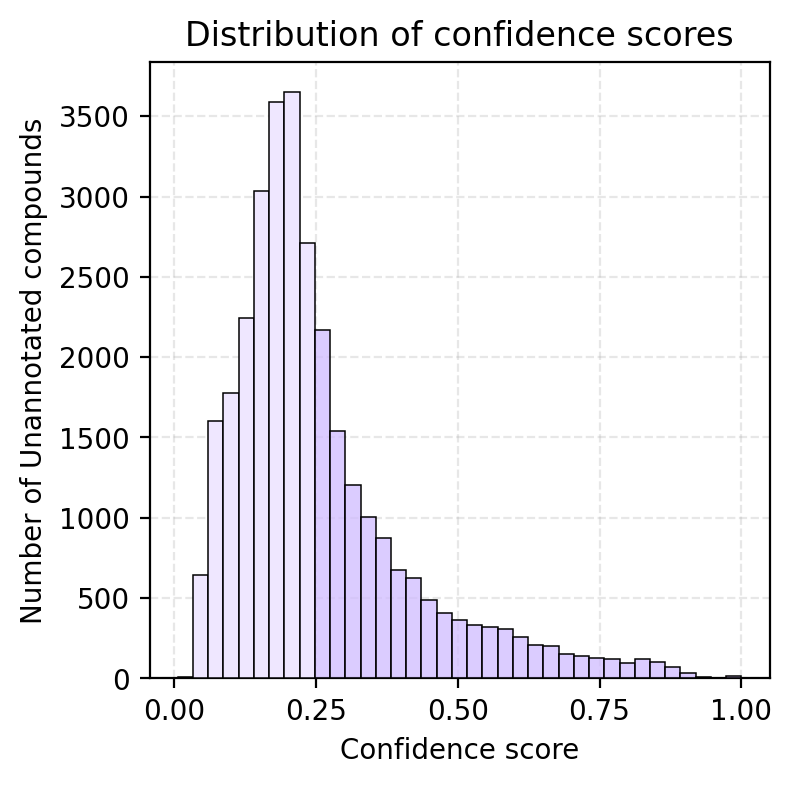

In [ ]:
base_color = sns.color_palette("pastel")[4]
light_color = tuple(min(1, c + (1 - c) * 0.65) for c in base_color)

plt.figure(figsize=(4,4), dpi=200)
ax = plt.gca()
sns.histplot(compound_top_c.top_conf, zorder=5, color=base_color, edgecolor="black", bins=37, ax=ax)
for patch in ax.patches:
    if patch.get_x() + patch.get_width() <= 0.25:
        patch.set_facecolor(light_color)
plt.xlabel("Confidence score")
plt.ylabel("Number of Unannotated compounds")
plt.title("Distribution of confidence scores")
plt.xticks(np.arange(0, 1.1, 0.25))
plt.grid(True, alpha=0.3, ls="--")
plt.show()


In [ ]:
compound_top_filtered = pd.read_csv(path_save + "MoA_inference_benchmark.csv")

In [ ]:
import ast
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def _to_clean_set(x):
    if x is None or pd.isna(x):
        return set()

    if isinstance(x, (list, tuple, set, np.ndarray)):
        items = list(x)
    else:
        s = str(x).strip()

        if s.startswith("[") and s.endswith("]"):
            try:
                parsed = ast.literal_eval(s)
                if isinstance(parsed, (list, tuple, set)):
                    items = list(parsed)
                else:
                    items = [s]
            except Exception:
                items = [s]
        else:
            items = re.split(r";|\|", s)

    return {
        str(i).strip().casefold()
        for i in items
        if str(i).strip() not in ["", "nan", "None"]
    }


def accuracy_above_threshold_aligned(
    df,
    measure="top_conf",
    thresholds=None,
    top_moa_col="top_moa",
    true_moa_col="true_moa",
):
    """
    Cumulative accuracy:
    for each threshold t, compute accuracy among compounds with confidence >= t.
    """

    d = df.copy()

    d["_top_moa_set"] = d[top_moa_col].apply(_to_clean_set)
    d["_true_moa_set"] = d[true_moa_col].apply(_to_clean_set)

    d["is_true"] = [
        len(a & b) > 0
        for a, b in zip(d["_top_moa_set"], d["_true_moa_set"])
    ]

    d = d[d[measure].notna()].copy()

    if thresholds is None:
        thresholds = np.linspace(0, 1, 21)

    rows = []

    for t in thresholds:
        subset = d[d[measure] >= t]

        n = len(subset)
        n_true = int(subset["is_true"].sum()) if n > 0 else 0

        if n > 0:
            pct_true = 100 * n_true / n
        else:
            pct_true = np.nan

        rows.append({
            "threshold": t,
            "n_compounds": n,
            "n_true": n_true,
            "pct_true": pct_true,
        })

    return pd.DataFrame(rows), d

In [ ]:
def plot_panel_A_confidence_threshold_line(
    compound_top_c,
    compound_top_filtered,
    conf_threshold=0.25,
    bins=None,
    figsize=(5.5, 4.6),
):
    if bins is None:
        bins = np.linspace(0, 1, 21)

    threshold_df, checked_df = accuracy_above_threshold_aligned(
        compound_top_filtered,
        measure="top_conf",
        thresholds=bins,
        top_moa_col="top_moa",
        true_moa_col="true_moa",
    )

    fig, (ax_top, ax_bottom) = plt.subplots(
        2, 1,
        figsize=figsize,
        dpi=300,
        sharex=True,
        gridspec_kw={
            "height_ratios": [0.8, 1.4],
            "hspace": 0.08,
        },
        facecolor="white",
    )

    base_color = sns.color_palette("pastel")[4]
    edge_color = sns.color_palette("tab10")[4]
    light_color = tuple(min(1, c + (1 - c) * 0.65) for c in base_color)

    # -----------------------------
    # Top: cumulative threshold accuracy
    # -----------------------------
    ax_top.plot(
        threshold_df["threshold"],
        threshold_df["pct_true"],
        marker="o",
        linewidth=1.8,
        markersize=3,
        color=edge_color,
    )

    ax_top.axvline(
        conf_threshold,
        color="black",
        linestyle="--",
        linewidth=1.0,
    )

    ax_top.set_ylabel("% true MOA")
    ax_top.set_ylim(0, 100)
    ax_top.grid(True, alpha=0.25, ls="--")
    ax_top.spines["top"].set_visible(False)
    ax_top.spines["right"].set_visible(False)

    # -----------------------------
    # Bottom: histogram
    # -----------------------------
    sns.histplot(
        compound_top_c["top_conf"].dropna(),
        bins=bins,
        color=base_color,
        edgecolor="black",
        ax=ax_bottom,
        zorder=3,
    )

    for patch in ax_bottom.patches:
        if patch.get_x() + patch.get_width() <= conf_threshold:
            patch.set_facecolor(light_color)

    ax_bottom.axvline(
        conf_threshold,
        color="black",
        linestyle="--",
        linewidth=1.0,
        zorder=5,
    )

    ax_bottom.text(
        conf_threshold + 0.015,
        ax_bottom.get_ylim()[1] * 0.92,
        f"threshold = {conf_threshold:.2f}",
        ha="left",
        va="top",
        fontsize=7,
    )

    ax_bottom.set_xlabel("Confidence score")
    ax_bottom.set_ylabel("Number of compounds")
    ax_bottom.set_xlim(0, 1)
    ax_bottom.set_xticks(np.arange(0, 1.01, 0.25))

    ax_bottom.grid(True, alpha=0.25, ls="--", zorder=0)
    ax_bottom.set_axisbelow(True)

    ax_bottom.spines["top"].set_visible(False)
    ax_bottom.spines["right"].set_visible(False)

    plt.tight_layout()

    return fig, (ax_top, ax_bottom), threshold_df, checked_df

/tmp/ipykernel_579629/3800392379.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


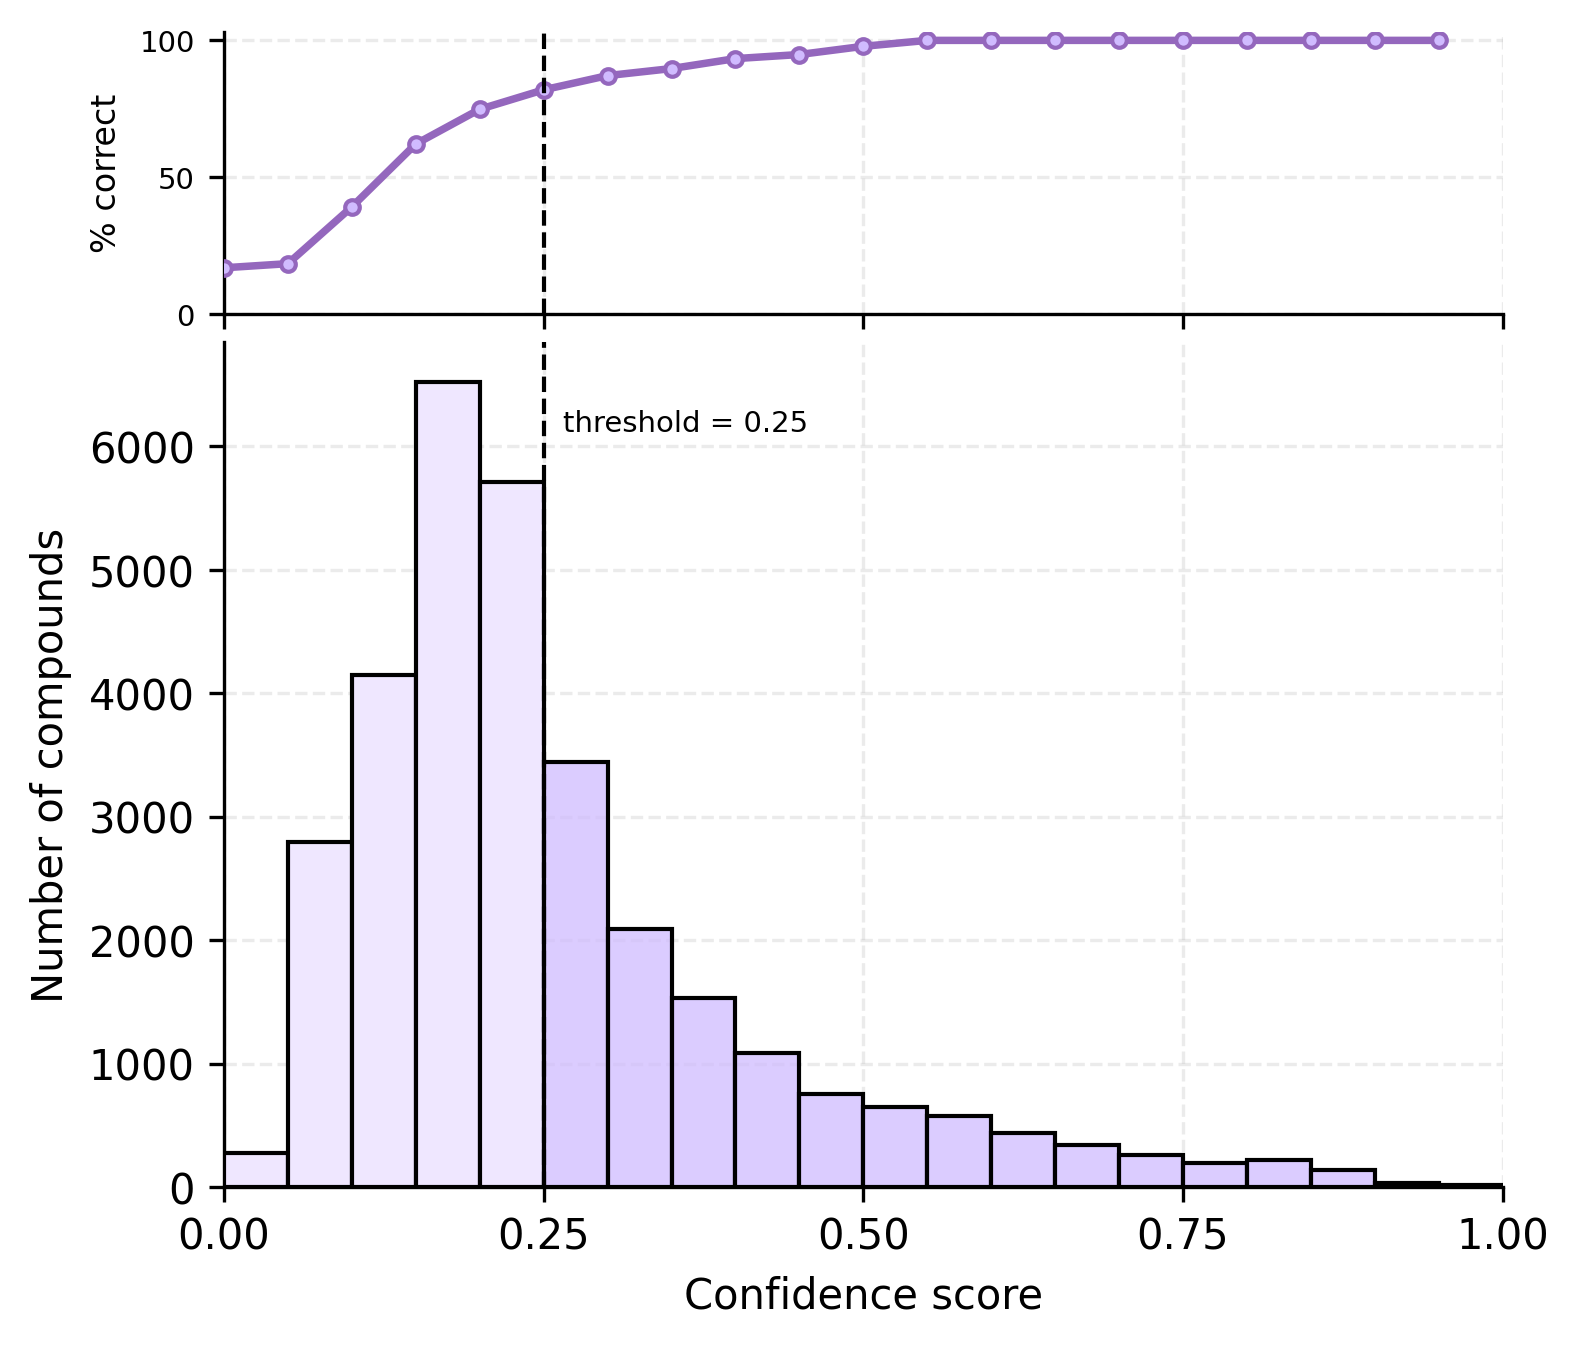

In [ ]:
bins = np.linspace(0, 1, 21)

fig, axes, threshold_df, checked_df = plot_panel_A_confidence_threshold_line(
    compound_top_c=compound_top_c,
    compound_top_filtered=compound_top_filtered,
    conf_threshold=0.25,
    bins=bins,
    figsize=(5.5, 5),
)

plt.show()

## B. TSNE

In [ ]:
cmp_info = pd.read_csv('./LINCS_scGPT_embeddings/Data/Intermediate_files/cmp_info.txt', sep = '\t')
cmp_info.dropna(subset=['moa'], inplace=True)


In [ ]:
moas_of_interest = ['HDAC inhibitor', 'Protein synthesis inhibitor', 'ATPase inhibitor', 'HSP inhibitor']

In [ ]:
compounds_of_interest = ['oxamflatin', 'HC-toxin', 'Fluoro-SAHA', 'cephaeline', 'emetine-hcl', 
                         'sarmentogenin', 'digitoxigenin', 'peruvoside', 'XL-888']

In [ ]:
annotated_compounds_moas = cmp_info[cmp_info.moa.isin(moas_of_interest)].cmap_name.unique()

In [ ]:
compound_top_c_selected = compound_top_c[compound_top_c.cmap_name.isin(compounds_of_interest)]

In [ ]:
root_LINCS = './LINCS_scGPT_embeddings/02_Obtain_Embeddings/embeddings_full.h5ad'
adata_FT = sc.read(root_LINCS)


In [ ]:
sample2cmap = dict(zip(adata_FT.obs_names, adata_FT.obs['cmap_name']))
cmp2moa = dict(zip(cmp_info[cmp_info.moa.isin(moas_of_interest)]['cmap_name'], cmp_info[cmp_info.moa.isin(moas_of_interest)]['moa']))
cmp2moa_pred = dict((zip(compound_top_c_selected.cmap_name, compound_top_c_selected.top_moa)))

In [ ]:
random_samples = np.concatenate([np.random.choice(adata_FT[adata_FT.obs.cmap_name == treatment].obs_names, size=min(len(adata_FT[adata_FT.obs.cmap_name == treatment].obs_names), 100), replace=False) for treatment in annotated_compounds_moas])
unanotated_cmp_interest = adata_FT[adata_FT.obs.cmap_name.isin(compounds_of_interest)].obs_names

In [ ]:
embs = np.concatenate([adata_FT[random_samples].obsm['X_scGPT'], adata_FT[unanotated_cmp_interest].obsm['X_scGPT']])
labels = np.array(['Annotated']*len(random_samples) + ['Unannotated']*len(unanotated_cmp_interest))
treatment = np.concatenate([adata_FT[random_samples].obs.cmap_name.values, adata_FT[unanotated_cmp_interest].obs.cmap_name.values]) 
moa_arr = np.concatenate([adata_FT[random_samples].obs.cmap_name.map(cmp2moa).values, adata_FT[unanotated_cmp_interest].obs.cmap_name.map(cmp2moa_pred).values])

from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=42)
embs_tsne = tsne.fit_transform(embs)


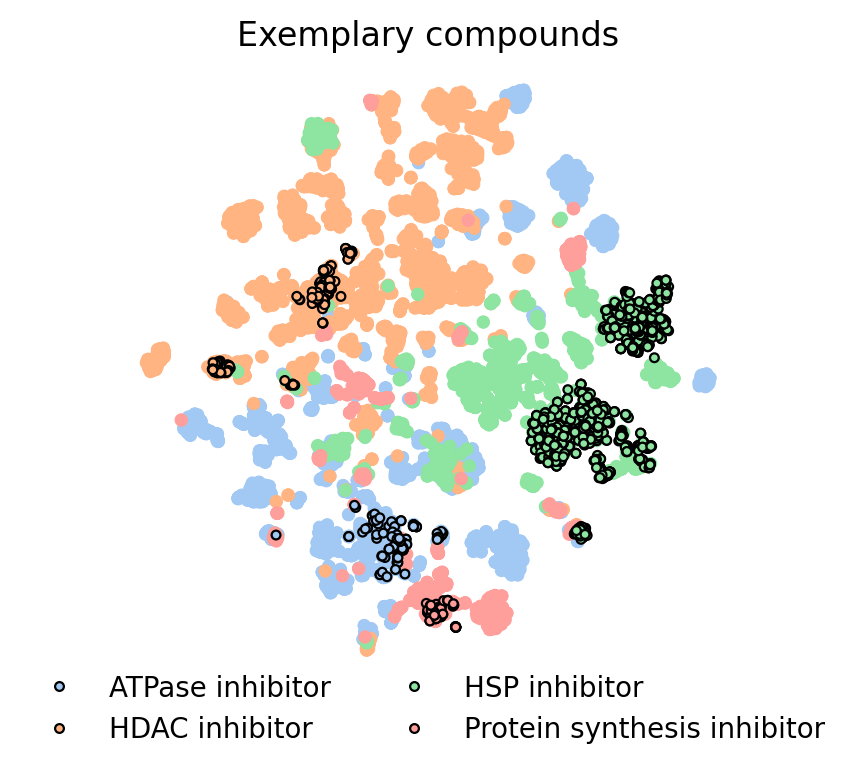

In [ ]:
plt.figure(figsize=(4,4), dpi=200)

is_external = labels == "Unannotated"
moas_plot = moa_arr.copy()
palette = dict(zip(np.unique(moas_plot), sns.color_palette('pastel', n_colors=len(np.unique(moas_plot)))))

for moa in np.unique(moas_plot):
    mask = (~is_external) & (moas_plot == moa)
    if mask.sum() == 0:
        continue
    sns.scatterplot(
        x=embs_tsne[mask, 0],
        y=embs_tsne[mask, 1],
        hue=np.repeat(moa, mask.sum()),
        hue_order=list(np.unique(moas_plot)),
        palette=palette,
        s=20,
        edgecolor=None,
        legend=False,
        alpha=1
    )

plot_order = list(np.unique(moas_plot))
ax = plt.gca()
for i, moa in enumerate(plot_order):
    mask = is_external & (moas_plot == moa)
    if mask.sum() == 0:
        continue
    sns.scatterplot(
        x=embs_tsne[mask, 0],
        y=embs_tsne[mask, 1],
        hue=np.repeat(moa, mask.sum()),
        hue_order=plot_order,
        palette=palette,
        s=10,
        edgecolor='black',
        linewidth=0.8,
        legend=(i == len(plot_order) - 1)
    )

plt.axis("off")
plt.title('Exemplary compounds')
plt.legend(loc='center', frameon=False, bbox_to_anchor=(0.5, -0.05),  ncols=2)
plt.show()

## C. Comparison of moa counts pre-post filter

In [ ]:
counts_total = pd.DataFrame(compound_top_c.top_moa.value_counts()).reset_index()

In [ ]:
counts_filtered = pd.DataFrame(compound_top_c[compound_top_c.top_conf > 0.25].top_moa.value_counts()[:10]).reset_index()

In [ ]:
moa_plot = counts_filtered[:10].top_moa.values

In [ ]:
counts_total = counts_total[counts_total.top_moa.isin(moa_plot)]
counts_filtered = counts_filtered[counts_filtered.top_moa.isin(moa_plot)]

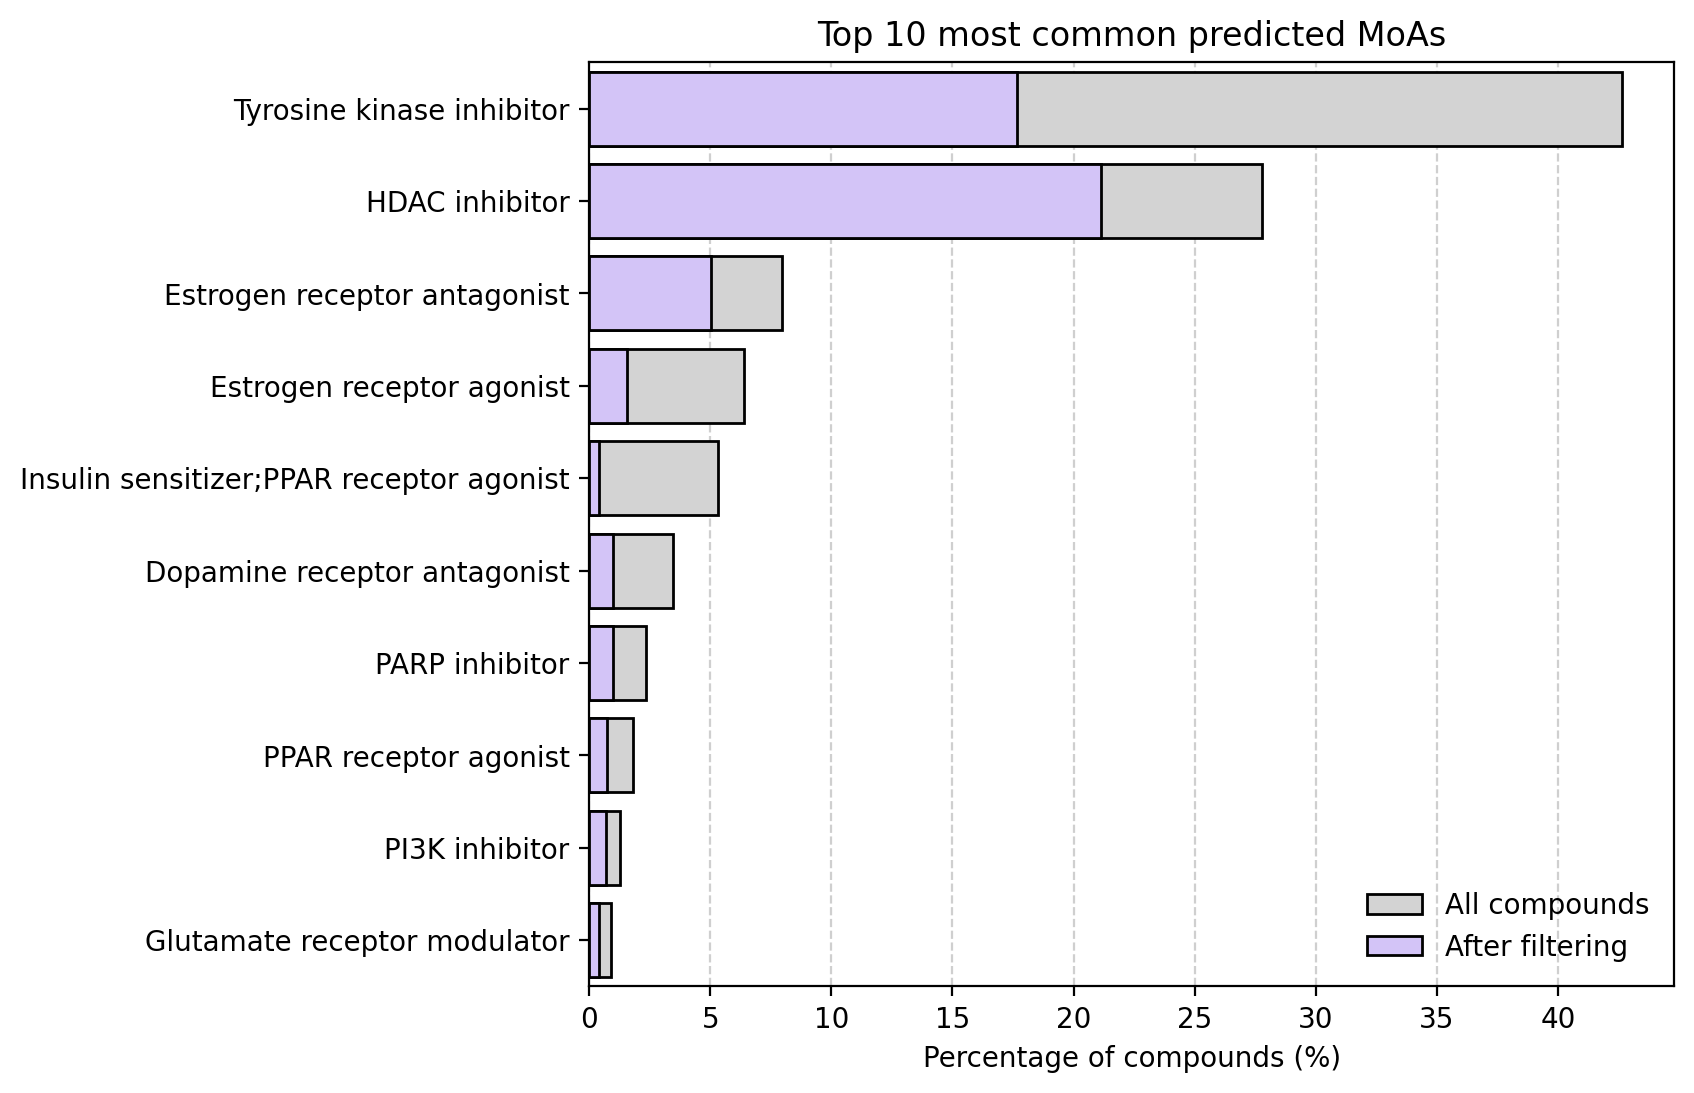

In [ ]:
def moa_counts_overlay(counts_total, counts_filtered, top_n=20):
    top_moas = counts_total.sort_values("count", ascending=False).head(top_n)["top_moa"].values

    total_lookup = counts_total.set_index("top_moa")["count"]
    filt_lookup  = counts_filtered.set_index("top_moa")["count"]

    plot_df = pd.DataFrame({
        "top_moa":    top_moas,
        "count_all":  total_lookup.reindex(top_moas, fill_value=0).values,
        "count_filt": filt_lookup.reindex(top_moas, fill_value=0).values,
    })
    n_total = counts_total["count"].sum()
    plot_df["perc_all"]  = plot_df["count_all"]  / n_total * 100
    plot_df["perc_filt"] = plot_df["count_filt"] / n_total * 100

    fig, ax = plt.subplots(figsize=(7, 6), dpi=200)

    sns.barplot(data=plot_df, y="top_moa", x="perc_all",
        color="lightgray", edgecolor="black", ax=ax, label="All compounds", zorder = 3)
    sns.barplot(data=plot_df, y="top_moa", x="perc_filt",
        color=sns.color_palette("pastel")[4], edgecolor="black", ax=ax, label="After filtering", zorder = 4)

    ax.set_xlabel("Percentage of compounds (%)")
    ax.set_ylabel("")
    ax.set_title(f"Top {top_n} most common predicted MoAs")

    # for i, row in plot_df.reset_index(drop=True).iterrows():
    #     ax.text(row["perc_all"] + 0.15, i,
    #         f'{int(row["count_filt"])}/{int(row["count_all"])}',
    #         va="center", fontsize=8, color="black")

    ax.legend(frameon=False)
    ax.grid(axis="x", linestyle="--", alpha=0.6, zorder=1)
    plt.show()


moa_counts_overlay(counts_total, counts_filtered, top_n=10) 


## D. Hit@100 sh-cmp - Robustness

In [ ]:
sh2cp = {'GW-843682X': 'PLK1',
 'MG-132': 'PSMB1',
 'clofarabine': 'RRM1',
 'roscovitine': 'CDK9',
 'selumetinib': 'MAP2K1',
 'AZD-8055': 'MTOR',
 'belinostat': 'HDAC6',
 'vemurafenib': 'BRAF',
 'ENMD-2076': 'AURKB',
 'SB-216763': 'GSK3A',
 'SJ-172550': 'MDM4',
 'NCH-51': 'HDAC2',
 'raltitrexed': 'TYMS'}

In [ ]:
## Distances and indices
# =============================================================================
# You need to run ./LINCS_scGPT_embeddings/03_Distance_Integration/NN_calculation.py using: 
# - reference: embeddings of compounds (trt_cp)
# - query: embeddings of genetic perturbations (trt_sh)


path_save = './LINCS_scGPT_embeddings/Results/compound_genetic_similarity/'
output_path = path_save + 'cmpvssh_nn.h5'
with h5py.File(output_path, 'r') as f:
    indices = f['indices'][:]

sig_id_order_cmp = pickle.load(open(path_save + 'order_sig_cmp.pkl', 'rb'))
sig_id_order_sh  = pickle.load(open(path_save + 'order_sig_sh.pkl',  'rb'))

In [ ]:
sig2cmap = dict(zip(adata_FT.obs_names, adata_FT.obs['cmap_name']))

In [ ]:
indices_bench = indices 
order_cmp_bench = sig_id_order_cmp 
cmap_order_cmp = [sig2cmap[i] for i in order_cmp_bench]
mask = np.isin(cmap_order_cmp, list(sh2cp.keys()))

indices_bench = indices_bench[mask]
order_cmp_bench = order_cmp_bench[mask]

cmap_order_cmp = [sig2cmap[i] for i in order_cmp_bench]
cmap_order_sh = [sig2cmap[i] for i in sig_id_order_sh]

import numpy as np
gene_by_sh_index = np.array(cmap_order_sh, dtype=object)


def topk_unique_genes_per_row(indices_bench, gene_by_sh_index, K_genes=100, max_scan=None):
    """
    indices_bench: (n_rows, K0) int array of ranked sh indices (neighbors).
    gene_by_sh_index: array-like mapping sh_idx -> gene (str or None)
    K_genes: number of unique genes to collect per row
    max_scan: how many sh neighbors to scan per row (default = all columns)

    Returns:
      genes_mat: (n_rows, K_genes) object array with gene symbols, padded with None if not enough genes.
    """
    n_rows, K0 = indices_bench.shape
    if max_scan is None:
        max_scan = K0

    genes_mat = np.full((n_rows, K_genes), None, dtype=object)

    for i in tqdm(range(n_rows)):
        seen = set()
        out = []
        for sh in indices_bench[i, :max_scan]:
            g = gene_by_sh_index[sh]
            if g is None:
                continue
            if g not in seen:
                seen.add(g)
                out.append(g)
                if len(out) == K_genes:
                    break
        genes_mat[i, :len(out)] = out

    return genes_mat


import pandas as pd


def build_compound_gene_robustness(
    indices_bench,
    gene_by_sh_index,
    order_cmp_bench,
    cmap_order_cmp,
    K_genes=100,
    max_scan=None,
):
    genes_mat = topk_unique_genes_per_row(
        indices_bench,
        gene_by_sh_index,
        K_genes=K_genes,
        max_scan=max_scan,
    )

    n_rows = genes_mat.shape[0]
    cp_sig = np.repeat(np.array(order_cmp_bench, dtype=object), genes_mat.shape[1])
    cp_name = np.repeat(np.array(cmap_order_cmp, dtype=object), genes_mat.shape[1])
    gene = genes_mat.reshape(-1)

    df_pairs = pd.DataFrame({
        "cp_sig": cp_sig,
        "compound": cp_name,
        "gene": gene,
    }).dropna(subset=["gene"]).copy()

    df_pairs = df_pairs.drop_duplicates(subset=["cp_sig", "gene"])

    support = (
        df_pairs.groupby(["compound", "gene"])["cp_sig"]
        .nunique()
        .rename("n_support")
        .reset_index()
    )

    n_cp_sigs = (
        pd.Series(cmap_order_cmp)
        .value_counts()
        .rename("n_cp_sigs")
        .reset_index()
        .rename(columns={"index": "compound"})
    )

    cg = support.merge(n_cp_sigs, on="compound", how="left")
    cg["robustness"] = cg["n_support"] / cg["n_cp_sigs"]

    # Build compound x top-K genes table ordered by robustness
    ranked = (
        cg.sort_values(["compound", "robustness"], ascending=[True, False])
        .groupby("compound", sort=False)
        .head(K_genes)
    )
    ranked["rank"] = ranked.groupby("compound").cumcount() + 1
    top_genes_df = ranked.pivot(index="compound", columns="rank", values="gene")
    top_genes_df.columns = [f"gene_{c}" for c in top_genes_df.columns]
    top_genes_df = top_genes_df.reset_index()

    return cg, genes_mat, top_genes_df


cg, genes_mat, top_genes_df = build_compound_gene_robustness(
    indices_bench,
    gene_by_sh_index,
    order_cmp_bench,
    cmap_order_cmp,
    K_genes=100,
)
K_GENES = genes_mat.shape[1]


In [ ]:
def get_target_metric_ranks(df, sh2cp, metric="robustness"):
    rows = []
    for compound, target_gene in sh2cp.items():
        sub = prepare_compound_metric_table(df, compound, metric=metric)
        if sub.empty:
            continue

        n_candidates = len(sub)
        target_rows = np.flatnonzero(sub["gene"].eq(target_gene).to_numpy())

        if len(target_rows) == 0:
            rows.append({
                "compound": compound,
                "target_gene": target_gene,
                "found": False,
                "rank0": np.nan,
                "rank1": np.nan,
                "percentile": np.nan,
                "n_candidates": n_candidates,
                "value": np.nan,
            })
            continue

        row_idx = int(target_rows[0])
        rank1 = int(sub.loc[row_idx, "rank1"])
        rank0 = rank1 - 1
        percentile = float(sub.loc[row_idx, "percentile"])
        rows.append({
            "compound": compound,
            "target_gene": target_gene,
            "found": True,
            "rank0": rank0,
            "rank1": rank1,
            "percentile": percentile,
            "n_candidates": n_candidates,
            "value": float(sub.loc[row_idx, metric]),
        })

    return pd.DataFrame(rows)


def shuffled_label_null_for_target_ranks(
    high_tas_indices,
    gene_by_sh_index,
    high_tas_order_cmp,
    high_tas_cmap_order_cmp,
    sh2cp,
    metric="robustness",
    n_perm=200,
    random_state=0,
    K_genes=100,
    max_scan=None,
):
    observed_cg, _, _ = build_compound_gene_robustness(
        high_tas_indices,
        gene_by_sh_index,
        high_tas_order_cmp,
        high_tas_cmap_order_cmp,
        K_genes=K_genes,
        max_scan=max_scan,
    )
    observed = get_target_metric_ranks(observed_cg, sh2cp, metric=metric)
    observed = observed[observed["found"]].copy().reset_index(drop=True)

    if observed.empty:
        raise ValueError("None of the expected target genes are present in the robustness table.")

    rng = np.random.default_rng(random_state)
    null_frames = []

    for perm in tqdm(range(n_perm)):
        shuffled_gene_by_sh_index = rng.permutation(np.asarray(gene_by_sh_index, dtype=object))
        shuffled_cg, _, _ = build_compound_gene_robustness(
            high_tas_indices,
            shuffled_gene_by_sh_index,
            high_tas_order_cmp,
            high_tas_cmap_order_cmp,
            K_genes=K_genes,
            max_scan=max_scan,
        )

        perm_ranks = get_target_metric_ranks(shuffled_cg, sh2cp, metric=metric)
        perm_ranks = perm_ranks[perm_ranks["compound"].isin(observed["compound"])].copy()
        perm_ranks["perm"] = perm
        null_frames.append(perm_ranks[["compound", "rank1", "percentile", "perm"]])

    null_rank_df = pd.concat(null_frames, ignore_index=True)

    null_summary = (
        null_rank_df.groupby("compound")
        .agg(
            null_rank1_mean=("rank1", "mean"),
            null_rank1_std=("rank1", "std"),
            null_percentile_mean=("percentile", "mean"),
            null_percentile_std=("percentile", "std"),
        )
        .reset_index()
    )

    rank_summary = observed.merge(null_summary, on="compound", how="left")

    observed_mean_percentile = rank_summary["percentile"].mean()
    null_mean_percentiles = (
        null_rank_df.groupby("perm")["percentile"]
        .mean()
        .rename("mean_percentile")
    )
    empirical_p = ((null_mean_percentiles >= observed_mean_percentile).sum() + 1) / (len(null_mean_percentiles) + 1)

    return rank_summary, null_rank_df, null_mean_percentiles, empirical_p


In [ ]:
rank_summary, null_rank_df, null_mean_percentiles, empirical_p = shuffled_label_null_for_target_ranks(
    indices_bench,
    gene_by_sh_index,
    order_cmp,
    cmap_order_cmp,
    sh2cp,
    metric="robustness",
    n_perm=200,
    random_state=0,
    K_genes=K_GENES,
)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


def _rank_transform(x, breakpoint=100, compress_after=0.05):
    """
    Piecewise transform:
    - 0..breakpoint shown with full resolution
    - values > breakpoint compressed
    """
    x = np.asarray(x, dtype=float)
    return np.where(
        x <= breakpoint,
        x,
        breakpoint + (x - breakpoint) * compress_after
    )


def _rank_ticks(max_val, breakpoint=100):
    """
    Dense ticks between 0 and 100 (every 10),
    sparse ticks after 100 to avoid overlap.
    """
    ticks_pre = list(range(0, breakpoint + 1, 15))
    ticks_post_candidates = [500, 1000, 2000, 5000, 10000]
    ticks_post = [t for t in ticks_post_candidates if t <= max_val]
    return ticks_pre + ticks_post


def plot_observed_vs_null_rank_lollipop(
    plot_df,
    compound_order=None,
    title="Observed vs shuffled-label null rank",
    observed_col="rank1",
    null_mean_col="null_rank1_mean",
    null_std_col="null_rank1_std",
    compound_col="compound",
    breakpoint=100,
    compress_after=0.05,
    xlim=None,
    xmin_raw=-5,   # <- empieza antes de 0
):
    d = plot_df.copy()

    # -------- order compounds --------
    if compound_order is None:
        labels = d[compound_col].tolist()
    else:
        labels = [c for c in compound_order if c in d[compound_col].values]
        d = d.set_index(compound_col).loc[labels].reset_index()

    # -------- values --------
    y = np.arange(len(d))
    observed = d[observed_col].astype(float).values
    null_mean = d[null_mean_col].astype(float).values
    null_std = d[null_std_col].astype(float).values

    # -------- colors --------

    null_color = sns.color_palette('pastel')[7]
    null_edge = 'gray'
    obs_face = sns.color_palette('pastel')[0]
    obs_edge = sns.color_palette("tab10")[0]

    # -------- figure (más alta que ancha) --------
    fig_h = max(7, 0.62 * len(d))
    fig, ax = plt.subplots(figsize=(4.8, fig_h), dpi=200)

    # -------- transformed x positions --------
    obs_t = _rank_transform(observed, breakpoint=breakpoint, compress_after=compress_after)
    mean_t = _rank_transform(null_mean, breakpoint=breakpoint, compress_after=compress_after)

    # transformed asymmetric error bars
    left_raw = np.clip(null_mean - null_std, 0, None)
    right_raw = null_mean + null_std

    left_t = _rank_transform(left_raw, breakpoint=breakpoint, compress_after=compress_after)
    right_t = _rank_transform(right_raw, breakpoint=breakpoint, compress_after=compress_after)

    xerr_left = mean_t - left_t
    xerr_right = right_t - mean_t
    xerr = np.vstack([xerr_left, xerr_right])

    # -------- shuffle null --------
    valid_null = np.isfinite(mean_t) & np.isfinite(xerr_left) & np.isfinite(xerr_right)
    ax.errorbar(
        mean_t[valid_null],
        y[valid_null],
        xerr=xerr[:, valid_null],
        fmt="o",
        color=null_edge,
        ecolor=null_color,
        elinewidth=2,
        capsize=3,
        markerfacecolor="white",
        markeredgecolor=null_edge,
        markeredgewidth=1.8,
        markersize=6.5,
        label="Shuffle null",
        zorder=3,
    )

    # -------- observed target --------
    valid_obs = np.isfinite(obs_t)
    ax.scatter(
        obs_t[valid_obs],
        y[valid_obs],
        s=70,
        color=obs_face,
        edgecolor=obs_edge,
        linewidth=1.2,
        label="Observed target",
        zorder=5,
    )

    # -------- y-axis --------
    ax.set_yticks(y)
    ax.set_yticklabels(d[compound_col])
    ax.invert_yaxis()

    # -------- x-axis --------
    max_val = np.nanmax([
        np.nanmax(observed),
        np.nanmax(null_mean + null_std)
    ])

    if xlim is None:
        xmax_raw = max_val * 1.05
    else:
        xmax_raw = xlim[1]

    tick_vals = _rank_ticks(xmax_raw, breakpoint=breakpoint)
    tick_pos = _rank_transform(tick_vals, breakpoint=breakpoint, compress_after=compress_after)

    ax.set_xticks(tick_pos)
    ax.set_xticklabels([str(t) for t in tick_vals], fontsize=8)

    xmin_t = _rank_transform([xmin_raw], breakpoint=breakpoint, compress_after=compress_after)[0]
    xmax_t = _rank_transform([xmax_raw], breakpoint=breakpoint, compress_after=compress_after)[0]
    ax.set_xlim(xmin_t, xmax_t)

    # separator at rank = 100 (lighter)
    bp_t = _rank_transform([breakpoint], breakpoint=breakpoint, compress_after=compress_after)[0]
    ax.axvline(bp_t, color="0.75", lw=0.8, alpha=0.55, zorder=0)

    # -------- cosmetics --------
    ax.set_xlabel("Target rank (lower = better)")
    ax.set_title(title)
    ax.grid(axis="x", linestyle="--", alpha=0.3)
    ax.legend(frameon=False, loc="best")

    plt.tight_layout()
    return fig, ax

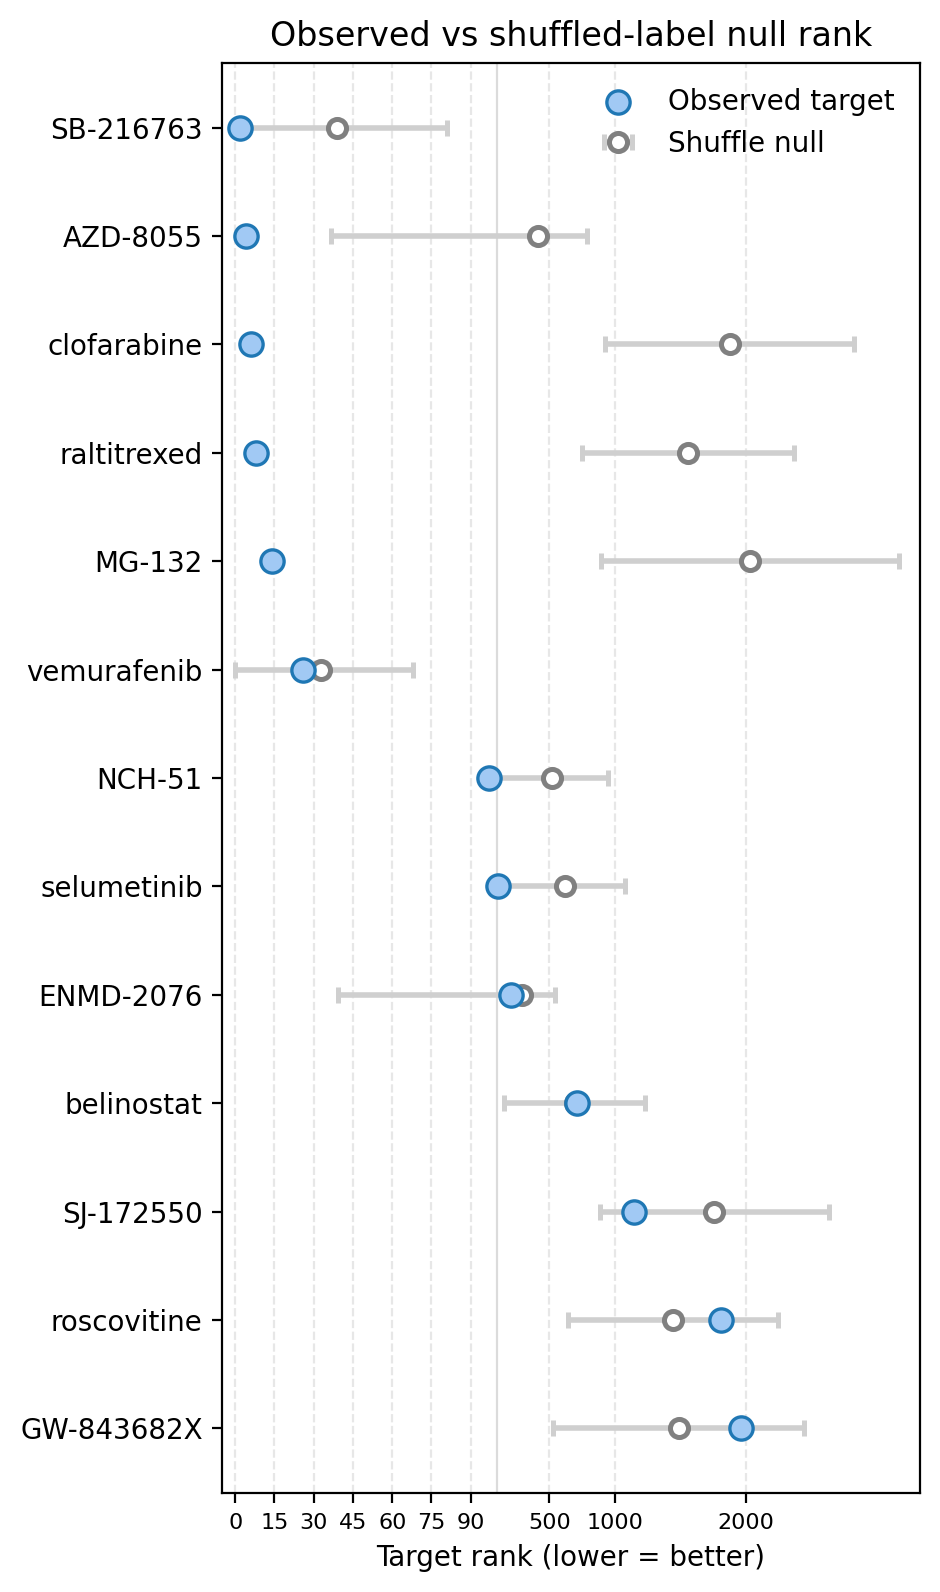

In [ ]:
plot_df = rank_summary.sort_values("rank1", ascending=True)

fig, ax = plot_observed_vs_null_rank_lollipop(plot_df)
plt.show()

## E1. Benchmark with CC 

In [ ]:
path_save = "./LINCS_scGPT_embeddings/Results/compound_genetic_similarity/"


conf = pd.read_csv(path_save + "compound_robustness_confidence.csv")
top_genes_df = pd.read_csv(path_save + "compound_top_genes_robustness.csv")



cc_targets = pickle.load(open("./LINCS_scGPT_embeddings/Data/Intermediate_files/compound_to_sign0_gene_symbols.pkl", "rb"))


In [5]:
import numpy as np
import pandas as pd


def compute_best_target_position(top_genes_df, cp2sh_frogs, K_genes=100):
    """
    For each compound in cp2sh_frogs, find the earliest rank at which one of
    its known target genes appears in top_genes_df.
    """
    gene_cols = [f"gene_{i}" for i in range(1, K_genes + 1)]

    top_df = top_genes_df.copy()
    top_df["_compound_key"] = top_df["compound"].astype(str).str.strip().str.casefold()

    comp_to_pred = {}
    comp_to_original_name = {}
    for _, row in top_df.iterrows():
        key = row["_compound_key"]
        genes = [
            row[col]
            for col in gene_cols
            if col in top_df.columns and isinstance(row[col], str)
        ]
        comp_to_pred[key] = genes
        comp_to_original_name[key] = row["compound"]

    records = []
    for compound, known_targets in cp2sh_frogs.items():
        compound_key = str(compound).strip().casefold()
        target_set = {
            str(g).strip().upper()
            for g in known_targets
            if isinstance(g, str)
        }

        if compound_key not in comp_to_pred:
            records.append({
                "compound": compound,
                "matched_compound": np.nan,
                "n_known_targets": len(target_set),
                "n_overlap": np.nan,
                "target_recall": np.nan,
                "target_precision": np.nan,
                "best_target_rank": np.nan,
                "best_target_gene": np.nan,
                "overlapping_targets": np.nan,
                "note": "compound_not_in_top_genes_df",
            })
            continue

        pred_genes = comp_to_pred[compound_key]
        pred_genes_norm = [
            str(g).strip().upper()
            for g in pred_genes
            if isinstance(g, str)
        ]
        pred_set = set(pred_genes_norm)

        overlap = target_set & pred_set
        n_overlap = len(overlap)
        target_recall = n_overlap / len(target_set) if target_set else 0.0
        target_precision = n_overlap / len(pred_set) if pred_set else 0.0

        best_rank = np.nan
        best_gene = np.nan
        for rank, gene in enumerate(pred_genes, start=1):
            if str(gene).strip().upper() in target_set:
                best_rank = rank
                best_gene = gene
                break

        records.append({
            "compound": compound,
            "matched_compound": comp_to_original_name[compound_key],
            "n_known_targets": len(target_set),
            "n_overlap": n_overlap,
            "target_recall": round(target_recall, 4),
            "target_precision": round(target_precision, 4),
            "best_target_rank": best_rank,
            "best_target_gene": best_gene,
            "overlapping_targets": ";".join(sorted(overlap)) if n_overlap > 0 else "",
            "note": "ok",
        })

    return pd.DataFrame(records)


In [6]:
target_position_df_cc = compute_best_target_position(
    top_genes_df=top_genes_df,
    cp2sh_frogs=cc_targets,
    K_genes=100,
)

observed_cc = target_position_df_cc[target_position_df_cc["note"] == "ok"].copy()
compound2rank = dict(zip(observed_cc["compound"], observed_cc["best_target_rank"]))

conf_bench_cc = conf[conf["compound"].isin(observed_cc["compound"] )].copy()
conf_bench_cc["robustness_rank"] = conf_bench_cc["compound"].map(compound2rank)
conf_bench_cc["recover"] = conf_bench_cc["robustness_rank"].notna()

compounds_mask = conf_bench_cc.loc[conf_bench_cc["recover"], "compound"].unique()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import PercentFormatter
from tqdm.auto import tqdm


def topk_unique_genes_per_row(indices_bench, gene_by_sh_index, K_genes=100, max_scan=None):
    """
    Collect the first K unique genes per compound row from the ranked shRNA hits.
    """
    n_rows, total_neighbors = indices_bench.shape
    if max_scan is None:
        max_scan = total_neighbors

    genes_mat = np.full((n_rows, K_genes), None, dtype=object)
    for i in tqdm(range(n_rows)):
        seen = set()
        out = []
        for sh_idx in indices_bench[i, :max_scan]:
            gene = gene_by_sh_index[sh_idx]
            if gene is None or gene in seen:
                continue
            seen.add(gene)
            out.append(gene)
            if len(out) == K_genes:
                break
        genes_mat[i, :len(out)] = out

    return genes_mat


def build_compound_gene_robustness(
    indices_bench,
    gene_by_sh_index,
    compound_sig_ids,
    compound_names,
    K_genes=100,
    max_scan=None,
):
    genes_mat = topk_unique_genes_per_row(
        indices_bench,
        gene_by_sh_index,
        K_genes=K_genes,
        max_scan=max_scan,
    )

    cp_sig = np.repeat(np.asarray(compound_sig_ids, dtype=object), genes_mat.shape[1])
    cp_name = np.repeat(np.asarray(compound_names, dtype=object), genes_mat.shape[1])
    gene = genes_mat.reshape(-1)

    df_pairs = pd.DataFrame({
        "cp_sig": cp_sig,
        "compound": cp_name,
        "gene": gene,
    }).dropna(subset=["gene"]).copy()
    df_pairs = df_pairs.drop_duplicates(subset=["cp_sig", "gene"])

    support = (
        df_pairs.groupby(["compound", "gene"])["cp_sig"]
        .nunique()
        .rename("n_support")
        .reset_index()
    )

    n_cp_sigs = (
        pd.Series(compound_names)
        .value_counts()
        .rename("n_cp_sigs")
        .rename_axis("compound")
        .reset_index()
    )

    cg = support.merge(n_cp_sigs, on="compound", how="left")
    cg["robustness"] = cg["n_support"] / cg["n_cp_sigs"]

    ranked = (
        cg.sort_values(["compound", "robustness"], ascending=[True, False])
        .groupby("compound", sort=False)
        .head(K_genes)
        .copy()
    )
    ranked["rank"] = ranked.groupby("compound").cumcount() + 1

    top_genes_df = ranked.pivot(index="compound", columns="rank", values="gene")
    top_genes_df.columns = [f"gene_{rank}" for rank in top_genes_df.columns]
    top_genes_df = top_genes_df.reset_index()

    return cg, genes_mat, top_genes_df


def prepare_compound_metric_table(df, compound, metric="robustness"):
    sub = df[df["compound"] == compound].copy()
    if sub.empty:
        return sub

    sub = sub.sort_values([metric, "gene"], ascending=[False, True]).reset_index(drop=True)
    sub["plot_position"] = np.arange(len(sub))
    sub["rank1"] = sub[metric].rank(method="min", ascending=False).astype(int)

    n_candidates = len(sub)
    rank0 = sub["rank1"] - 1
    sub["percentile"] = 100.0 if n_candidates == 1 else 100.0 * (1.0 - rank0 / (n_candidates - 1))
    return sub


def _as_target_list(targets):
    if targets is None:
        return []
    if isinstance(targets, str):
        return [targets]
    try:
        return [target for target in list(targets) if pd.notna(target)]
    except TypeError:
        return [targets]


def _select_best_target_row(sub, target_genes, metric="robustness"):
    target_rows = sub[sub["gene"].isin(_as_target_list(target_genes))].copy()
    if target_rows.empty:
        return None, target_rows

    best_row = (
        target_rows
        .sort_values(["rank1", metric, "gene"], ascending=[True, False, True])
        .iloc[0]
    )
    return best_row, target_rows


def get_best_target_metric_ranks(df, compound_to_targets, metric="robustness", missing="nan"):
    rows = []

    for compound, target_genes_raw in compound_to_targets.items():
        target_genes = _as_target_list(target_genes_raw)
        sub = prepare_compound_metric_table(df, compound, metric=metric)

        if sub.empty:
            rows.append({
                "compound": compound,
                "target_genes": target_genes,
                "target_gene": np.nan,
                "found": False,
                "rank0": np.nan,
                "rank1": np.nan,
                "percentile": np.nan,
                "n_candidates": 0,
                "n_targets_input": len(target_genes),
                "n_targets_found": 0,
                "value": np.nan,
            })
            continue

        n_candidates = len(sub)
        best_row, target_rows = _select_best_target_row(sub, target_genes, metric=metric)

        if best_row is None:
            if missing == "worst":
                rank1 = n_candidates + 1
                rank0 = n_candidates
                percentile = 0.0
            else:
                rank1 = np.nan
                rank0 = np.nan
                percentile = np.nan

            rows.append({
                "compound": compound,
                "target_genes": target_genes,
                "target_gene": np.nan,
                "found": False,
                "rank0": rank0,
                "rank1": rank1,
                "percentile": percentile,
                "n_candidates": n_candidates,
                "n_targets_input": len(target_genes),
                "n_targets_found": 0,
                "value": np.nan,
            })
            continue

        rows.append({
            "compound": compound,
            "target_genes": target_genes,
            "target_gene": best_row["gene"],
            "found": True,
            "rank0": int(best_row["rank1"]) - 1,
            "rank1": int(best_row["rank1"]),
            "percentile": float(best_row["percentile"]),
            "n_candidates": n_candidates,
            "n_targets_input": len(target_genes),
            "n_targets_found": len(target_rows),
            "value": float(best_row[metric]),
        })

    return pd.DataFrame(rows)


def _empirical_p(null_values, observed_value, direction="higher"):
    null_values = pd.Series(null_values).dropna()
    if len(null_values) == 0:
        return np.nan
    if direction == "higher":
        return ((null_values >= observed_value).sum() + 1) / (len(null_values) + 1)
    if direction == "lower":
        return ((null_values <= observed_value).sum() + 1) / (len(null_values) + 1)
    raise ValueError("direction must be 'higher' or 'lower'")


def shuffled_label_null_for_best_target_ranks(
    indices_bench,
    gene_by_sh_index,
    compound_sig_ids,
    compound_names,
    compound_to_targets,
    metric="robustness",
    n_perm=200,
    random_state=0,
    K_genes=100,
    max_scan=None,
    missing_in_null="worst",
):
    observed_cg, _, _ = build_compound_gene_robustness(
        indices_bench,
        gene_by_sh_index,
        compound_sig_ids,
        compound_names,
        K_genes=K_genes,
        max_scan=max_scan,
    )

    observed = get_best_target_metric_ranks(
        observed_cg,
        compound_to_targets,
        metric=metric,
        missing="nan",
    )
    observed = observed[observed["found"]].copy().reset_index(drop=True)

    if observed.empty:
        raise ValueError("None of the expected target genes were present in the observed robustness table.")

    observed_compounds = observed["compound"].tolist()
    observed_targets = {
        compound: compound_to_targets[compound]
        for compound in observed_compounds
    }

    rng = np.random.default_rng(random_state)
    null_frames = []
    for perm in tqdm(range(n_perm)):
        shuffled_gene_by_sh_index = rng.permutation(np.asarray(gene_by_sh_index, dtype=object))
        shuffled_cg, _, _ = build_compound_gene_robustness(
            indices_bench,
            shuffled_gene_by_sh_index,
            compound_sig_ids,
            compound_names,
            K_genes=K_genes,
            max_scan=max_scan,
        )
        perm_ranks = get_best_target_metric_ranks(
            shuffled_cg,
            observed_targets,
            metric=metric,
            missing=missing_in_null,
        )
        perm_ranks["perm"] = perm
        null_frames.append(
            perm_ranks[["compound", "target_gene", "found", "rank1", "percentile", "value", "perm"]]
        )

    null_rank_df = pd.concat(null_frames, ignore_index=True)

    null_summary = (
        null_rank_df.groupby("compound")
        .agg(
            null_rank1_mean=("rank1", "mean"),
            null_rank1_std=("rank1", "std"),
            null_percentile_mean=("percentile", "mean"),
            null_percentile_std=("percentile", "std"),
            null_robustness_mean=("value", "mean"),
            null_robustness_std=("value", "std"),
            null_found_rate=("found", "mean"),
        )
        .reset_index()
    )

    rank_summary = observed.merge(null_summary, on="compound", how="left")

    null_means = (
        null_rank_df.groupby("perm")
        .agg(
            mean_rank1=("rank1", "mean"),
            mean_percentile=("percentile", "mean"),
            mean_robustness=("value", "mean"),
        )
        .reset_index()
    )

    diagnostics = {
        "observed_mean_rank1": rank_summary["rank1"].mean(),
        "observed_mean_percentile": rank_summary["percentile"].mean(),
        "observed_mean_robustness": rank_summary["value"].mean(),
        "empirical_p_mean_rank1_lower": _empirical_p(null_means["mean_rank1"], rank_summary["rank1"].mean(), direction="lower"),
        "empirical_p_mean_percentile_higher": _empirical_p(null_means["mean_percentile"], rank_summary["percentile"].mean(), direction="higher"),
        "empirical_p_mean_robustness_higher": _empirical_p(null_means["mean_robustness"], rank_summary["value"].mean(), direction="higher"),
    }

    return rank_summary, null_rank_df, null_means, diagnostics


def compute_cumulative_from_rank_summary_selected_compounds(
    rank_summary,
    selected_compounds,
    k_max=100,
    compound_col="compound",
    observed_rank_col="rank1",
    null_mean_col="null_rank1_mean",
):
    d = rank_summary.copy()
    d = d[
        d[compound_col].isin(selected_compounds)
        & d[observed_rank_col].notna()
        & d[null_mean_col].notna()
    ].copy()

    rows = []
    for k in range(1, k_max + 1):
        rows.append({
            "k": k,
            "observed_frac": (d[observed_rank_col] <= k).mean(),
            "null_mean_frac": (d[null_mean_col] <= k).mean(),
            "n_compounds": len(d),
        })

    return pd.DataFrame(rows), d


def plot_panel_E_combined(
    conf_bench,
    rank_summary,
    topk=100,
    k_max=100,
    compound_col="compound",
    recover_col="recover",
    observed_rank_col="rank1",
    null_mean_col="null_rank1_mean",
    figsize=(6.2, 6.2),
    title=None,
):
    cb = conf_bench.copy()
    if recover_col not in cb.columns:
        raise ValueError(f"Column '{recover_col}' not found in conf_bench.")

    cb = cb[cb[compound_col].notna()].copy()
    cb[recover_col] = cb[recover_col].astype(bool)

    n_topk = int(cb[recover_col].sum())
    n_not_topk = int((~cb[recover_col]).sum())
    n_total = len(cb)
    recovered_compounds = cb.loc[cb[recover_col], compound_col].dropna().unique().tolist()

    curve_df, used_rank_df = compute_cumulative_from_rank_summary_selected_compounds(
        rank_summary=rank_summary,
        selected_compounds=recovered_compounds,
        k_max=k_max,
        compound_col=compound_col,
        observed_rank_col=observed_rank_col,
        null_mean_col=null_mean_col,
    )

    true_fill = sns.color_palette("pastel")[2]
    false_fill = sns.color_palette("pastel")[1]
    true_edge = sns.color_palette("tab10")[2]
    false_edge = sns.color_palette("tab10")[1]
    observed_fill = sns.color_palette("pastel")[0]
    observed_line = sns.color_palette("tab10")[0]
    null_fill = sns.color_palette("pastel")[7]
    null_line = "gray"

    fig = plt.figure(figsize=figsize, dpi=200)
    gs = GridSpec(2, 1, height_ratios=[0.85, 2.5], hspace=0.06)
    ax_top = fig.add_subplot(gs[0])
    ax_bottom = fig.add_subplot(gs[1])

    labels = [f"In Top-{topk}", f"Not in Top-{topk}"]
    counts = [n_topk, n_not_topk]
    y = np.array([1, 0])
    bars = ax_top.barh(
        y,
        counts,
        color=[true_fill, false_fill],
        edgecolor=[true_edge, false_edge],
        linewidth=1.5,
        height=0.55,
        zorder=3,
    )

    ax_top.set_yticks(y)
    ax_top.set_yticklabels(labels, fontsize=9)
    xmax = max(counts) if counts else 1
    ax_top.set_xlim(0, xmax * 1.18)

    for yi, count, bar in zip(y, counts, bars):
        pct = 100 * count / n_total if n_total > 0 else 0
        x_text = count - xmax * 0.03 if count > xmax * 0.18 else count + xmax * 0.02
        ha = "right" if count > xmax * 0.18 else "left"
        ax_top.text(x_text, yi, f"{count} ({pct:.1f}%)", va="center", ha=ha, fontsize=9, color="black")

    if title is not None:
        ax_top.set_title(title, fontsize=10)

    ax_top.tick_params(axis="x", bottom=False, labelbottom=False)
    ax_top.grid(False)
    for spine in ["top", "right", "bottom", "left"]:
        ax_top.spines[spine].set_visible(False)

    ax_bottom.fill_between(curve_df["k"], curve_df["null_mean_frac"], 0, step="post", color=null_fill, alpha=0.85, label="Shuffle null mean", zorder=2)
    ax_bottom.fill_between(curve_df["k"], curve_df["observed_frac"], 0, step="post", color=observed_fill, alpha=0.85, label="Observed", zorder=1)
    ax_bottom.step(curve_df["k"], curve_df["null_mean_frac"], where="post", color=null_line, linewidth=2, zorder=3)
    ax_bottom.step(curve_df["k"], curve_df["observed_frac"], where="post", color=observed_line, linewidth=2.3, zorder=4)

    ax_bottom.set_xlim(1, k_max)
    ax_bottom.set_ylim(0, 1.02)
    ax_bottom.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax_bottom.set_xlabel("Rank threshold (k)")
    ax_bottom.set_ylabel(f"Fraction of Top-{topk} compounds\nwith rank ≤ k")
    ax_bottom.grid(True, linestyle="--", alpha=0.3)
    ax_bottom.set_axisbelow(True)
    ax_bottom.legend(frameon=False, loc="upper left", fontsize=8)
    ax_bottom.spines["top"].set_visible(False)
    ax_bottom.spines["right"].set_visible(False)

    plt.tight_layout()
    return fig, (ax_top, ax_bottom), curve_df, used_rank_df

In [13]:

high_tas_cmap_order_cmp = np.array([sig2cmap[i] for i in sig_id_order_cmp], dtype=object)
high_tas_mask = np.isin(high_tas_cmap_order_cmp, compounds_mask)

high_tas_indices_cc = indices[high_tas_mask]
high_tas_order_cmp_cc = sig_id_order_cmp[high_tas_mask]
high_tas_cmap_order_cmp_cc = high_tas_cmap_order_cmp[high_tas_mask]
gene_by_sh_index_cc = np.array([sig2cmap[i] for i in sig_id_order_sh], dtype=object)

cc_targets = {
    compound: targets
    for compound, targets in cc_targets.items()
    if compound in compounds_mask
}

cg_cc, genes_mat_cc, top_genes_df_cc = build_compound_gene_robustness(
    high_tas_indices_cc,
    gene_by_sh_index_cc,
    high_tas_order_cmp_cc,
    high_tas_cmap_order_cmp_cc,
    K_genes=100,
)
K_GENES_CC = genes_mat_cc.shape[1]

robustness_summary_cc = get_best_target_metric_ranks(
    cg_cc,
    cc_targets,
    metric="robustness",
    missing="nan",
)
robustness_summary_cc = robustness_summary_cc[robustness_summary_cc["found"]].copy()


  0%|          | 0/276379 [00:00<?, ?it/s]

In [ ]:
rank_summary_cc, null_rank_df_cc, null_means_cc, diagnostics_cc = shuffled_label_null_for_best_target_ranks(
    high_tas_indices_cc,
    gene_by_sh_index_cc,
    high_tas_order_cmp_cc,
    high_tas_cmap_order_cmp_cc,
    cc_targets,
    metric="robustness",
    n_perm=200,
    random_state=0,
    K_genes=K_GENES_CC,
    max_scan=None,
)


  0%|          | 0/276379 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/276379 [00:00<?, ?it/s]

  0%|          | 0/276379 [00:00<?, ?it/s]

/tmp/ipykernel_2797010/1457421303.py:434: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


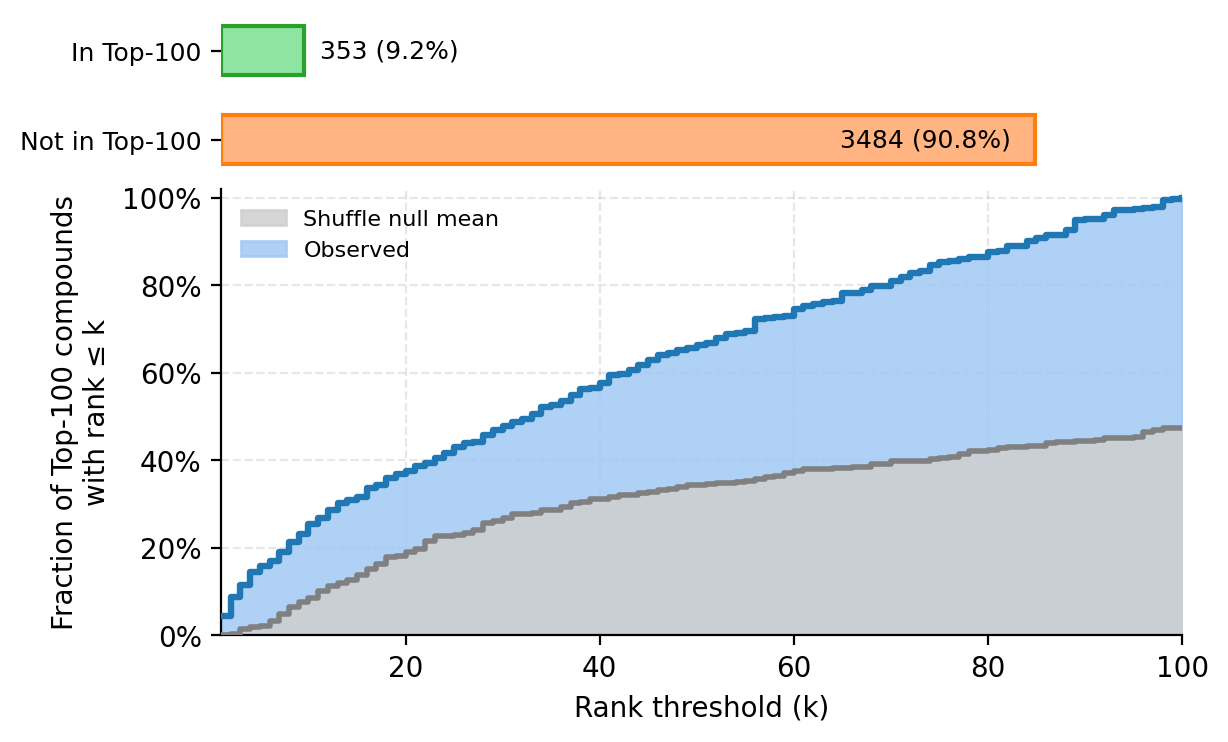

In [17]:
fig, axes, curve_df, used_rank_df = plot_panel_E_combined(
    conf_bench=conf_bench_cc,
    rank_summary=rank_summary_cc,
    topk=100,
    k_max=100,
    compound_col="compound",
    recover_col="recover",
    observed_rank_col="rank1",
    null_mean_col="null_rank1_mean",
    figsize=(6.2, 4),
    title=None,
)

plt.show()


## E2. Benchmark with FRoGS 

In [ ]:
# =============================================================================
# Download the cmp to target mapping from FRoGS github repo (https://github.com/chenhcs/FRoGS/blob/main/data/cpd_gene_pairs.csv)
# frogs_targets = pickle.load(open('./LINCS_scGPT_embeddings/cpd2target_names.pkl', 'rb'))

target_position_df_frogs = compute_best_target_position(
    top_genes_df=top_genes_df,
    cp2sh_frogs=frogs_targets,
    K_genes=100,
)
target_position_df = target_position_df_frogs

observed_frogs = target_position_df_frogs[target_position_df_frogs["note"] == "ok"].copy()
compound2rank_frogs = dict(zip(observed_frogs["compound"], observed_frogs["best_target_rank"]))

conf_bench_frogs = conf[conf["compound"].isin(observed_frogs["compound"])].copy()
conf_bench_frogs["robustness_rank"] = conf_bench_frogs["compound"].map(compound2rank_frogs)
conf_bench_frogs["recover"] = conf_bench_frogs["robustness_rank"].notna()
conf_bench = conf_bench_frogs

frogs_compounds_mask = conf_bench_frogs.loc[conf_bench_frogs["recover"], "compound"].unique()
high_tas_mask_frogs = np.isin(high_tas_cmap_order_cmp, frogs_compounds_mask)

high_tas_indices_frogs = indices[high_tas_mask_frogs]
high_tas_order_cmp_frogs = sig_id_order_cmp[high_tas_mask_frogs]
high_tas_cmap_order_cmp_frogs = high_tas_cmap_order_cmp[high_tas_mask_frogs]
gene_by_sh_index_frogs = gene_by_sh_index_cc

frogs_targets = {
    compound: targets
    for compound, targets in frogs_targets.items()
    if compound in frogs_compounds_mask
}

cg_frogs, genes_mat_frogs, top_genes_df_frogs = build_compound_gene_robustness(
    high_tas_indices_frogs,
    gene_by_sh_index_frogs,
    high_tas_order_cmp_frogs,
    high_tas_cmap_order_cmp_frogs,
    K_genes=100,
)
K_GENES_FROGS = genes_mat_frogs.shape[1]


  0%|          | 0/209242 [00:00<?, ?it/s]

In [ ]:
robustness_summary_frogs = get_best_target_metric_ranks(
    cg_frogs,
    frogs_targets,
    metric="robustness",
    missing="nan",
)
robustness_summary_frogs = robustness_summary_frogs[robustness_summary_frogs["found"]].copy()

rank_summary_frogs, null_rank_df_frogs, null_means_frogs, diagnostics_frogs = shuffled_label_null_for_best_target_ranks(
    high_tas_indices_frogs,
    gene_by_sh_index_frogs,
    high_tas_order_cmp_frogs,
    high_tas_cmap_order_cmp_frogs,
    frogs_targets,
    metric="robustness",
    n_perm=200,
    random_state=0,
    K_genes=K_GENES_FROGS,
    max_scan=None,
)


  0%|          | 0/209242 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/209242 [00:00<?, ?it/s]

  0%|          | 0/209242 [00:00<?, ?it/s]

/tmp/ipykernel_2797010/1457421303.py:434: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


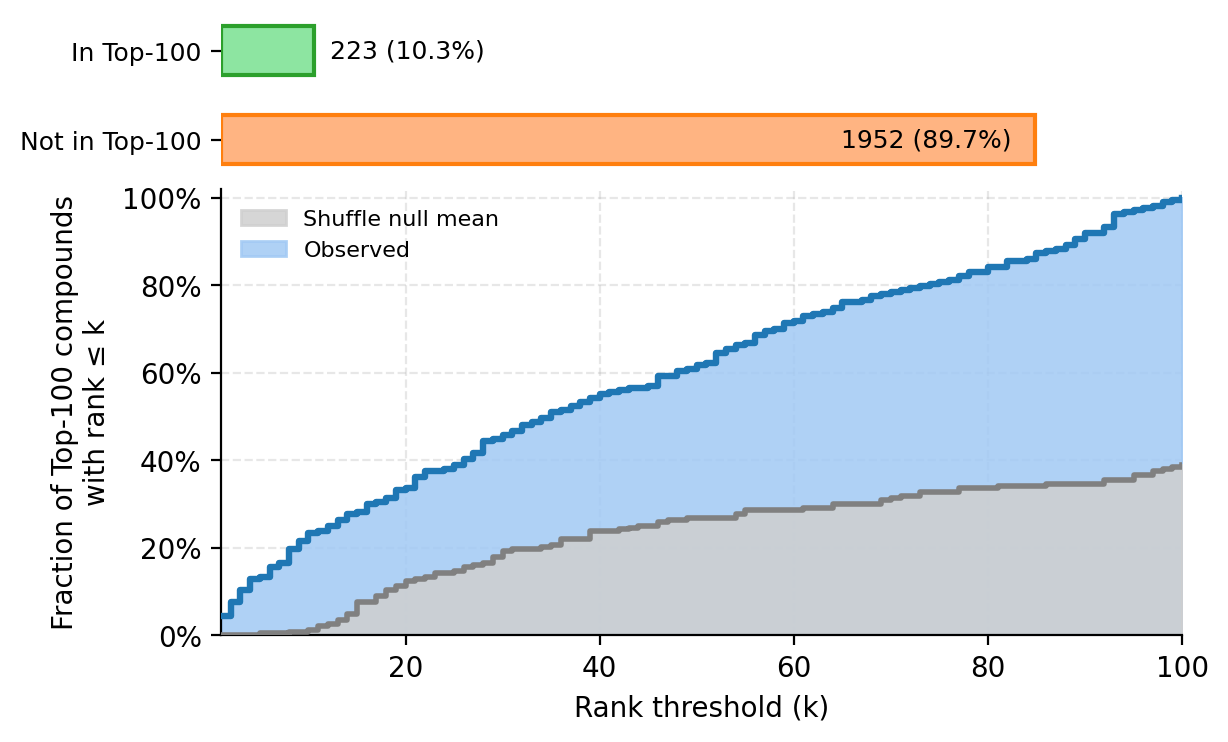

In [20]:
fig, axes, curve_df, used_rank_df = plot_panel_E_combined(
    conf_bench=conf_bench_frogs,
    rank_summary=rank_summary_frogs,
    topk=100,
    k_max=100,
    compound_col="compound",
    recover_col="recover",
    observed_rank_col="rank1",
    null_mean_col="null_rank1_mean",
    figsize=(6.2, 4),
    title=None,
)

plt.show()

## F. Scores

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
from scipy.stats import mannwhitneyu


def _lighten_color(color, amount=0.45):
    """
    Lighten a color by mixing it with white.
    amount=0 -> original color
    amount=1 -> white
    """
    c = np.array(mcolors.to_rgb(color))
    white = np.array([1, 1, 1])
    return tuple((1 - amount) * c + amount * white)


def _p_to_star(p):
    if pd.isna(p):
        return ""
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


def _composite_recovery_pvalue(df, composite_col):
    """
    One-sided Mann-Whitney U test:
    recovered scores > non-recovered scores.
    """
    false_vals = df.loc[df["recover"] == False, composite_col].dropna().values
    true_vals = df.loc[df["recover"] == True, composite_col].dropna().values

    if len(false_vals) == 0 or len(true_vals) == 0:
        return np.nan

    return mannwhitneyu(
        true_vals,
        false_vals,
        alternative="greater"
    ).pvalue


def _boxplot_upper_whisker(vals):
    """
    Approximate the visible upper whisker used by matplotlib boxplot.
    This keeps stars close to the visible boxplot, not to hidden outliers.
    """
    vals = pd.Series(vals).dropna().values

    if len(vals) == 0:
        return np.nan

    q1, q3 = np.percentile(vals, [25, 75])
    iqr = q3 - q1
    upper_limit = q3 + 1.5 * iqr

    visible_vals = vals[vals <= upper_limit]

    if len(visible_vals) == 0:
        return np.nanmax(vals)

    return np.nanmax(visible_vals)


def plot_score_boxplots_two_dfs_vertical(
    conf_bench,
    conf_bench_cc,
    composite_col="composite_score",
    figsize=(6.5, 8.5),
    showfliers=False,
    title="Score distributions by recovery status",
    xlim=None,
    star_dx=0.03,
):
    """
    Horizontal boxplots:
    - metrics on Y axis
    - score on X axis
    - 4 boxplots per metric:
        FRoGS / recover=False
        FRoGS / recover=True
        CC / recover=False
        CC / recover=True

    Colors:
    - CC recovered: pastel[2] fill, tab10[2] edge
    - CC not recovered: pastel[1] fill, tab10[1] edge
    - FRoGS: lighter versions of the same colors
    - Composite: black borders / whiskers / caps / median

    Statistics:
    - only Composite is annotated
    - one-sided Mann-Whitney U test:
        recovered > non-recovered
    """

    # -------------------------
    # metrics
    # -------------------------
    metric_order = [
        "score_n_sigs",
        "score_tas",
        "score_enrichment",
        "score_robustness",
        composite_col,
    ]

    metric_labels = {
        "score_n_sigs": "# samples",
        "score_tas": "TAS",
        "score_enrichment": "Enrichment",
        "score_robustness": "Robustness",
        composite_col: "Composite",
    }

    # -------------------------
    # colors
    # -------------------------
    cc_true_fill = sns.color_palette("pastel")[2]
    cc_false_fill = sns.color_palette("pastel")[1]

    cc_true_edge = sns.color_palette("tab10")[2]
    cc_false_edge = sns.color_palette("tab10")[1]

    frogs_true_fill = _lighten_color(cc_true_fill, amount=0.65)
    frogs_false_fill = _lighten_color(cc_false_fill, amount=0.65)

    frogs_true_edge = _lighten_color(cc_true_edge, amount=0.55)
    frogs_false_edge = _lighten_color(cc_false_edge, amount=0.55)

    fill_colors = {
        ("conf_bench", False): frogs_false_fill,
        ("conf_bench", True): frogs_true_fill,
        ("conf_bench_cc", False): cc_false_fill,
        ("conf_bench_cc", True): cc_true_fill,
    }

    edge_colors = {
        ("conf_bench", False): frogs_false_edge,
        ("conf_bench", True): frogs_true_edge,
        ("conf_bench_cc", False): cc_false_edge,
        ("conf_bench_cc", True): cc_true_edge,
    }

    dataset_frames = {
        "conf_bench": conf_bench.copy(),
        "conf_bench_cc": conf_bench_cc.copy(),
    }

    group_order = [
        ("conf_bench", False),
        ("conf_bench", True),
        ("conf_bench_cc", False),
        ("conf_bench_cc", True),
    ]

    group_labels = {
        ("conf_bench", False): "FRoGS · False",
        ("conf_bench", True): "FRoGS · True",
        ("conf_bench_cc", False): "CC · False",
        ("conf_bench_cc", True): "CC · True",
    }

    offsets = {
        ("conf_bench", False): -0.27,
        ("conf_bench", True): -0.09,
        ("conf_bench_cc", False): 0.09,
        ("conf_bench_cc", True): 0.27,
    }

    box_width = 0.14

    # -------------------------
    # figure
    # -------------------------
    fig, ax = plt.subplots(figsize=figsize, dpi=200)

    # -------------------------
    # draw horizontal boxplots
    # -------------------------
    for i, metric in enumerate(metric_order):
        for dataset_name, rec in group_order:
            df = dataset_frames[dataset_name]

            if metric not in df.columns:
                continue

            vals = df.loc[df["recover"] == rec, metric].dropna().values

            if len(vals) == 0:
                continue

            pos = i + offsets[(dataset_name, rec)]
            face = fill_colors[(dataset_name, rec)]

            if metric == composite_col:
                edge = "black"
            else:
                edge = edge_colors[(dataset_name, rec)]

            bp = ax.boxplot(
                [vals],
                positions=[pos],
                widths=box_width,
                vert=False,
                patch_artist=True,
                showfliers=showfliers,
                manage_ticks=False,
                zorder=3,
            )

            for box in bp["boxes"]:
                box.set(
                    facecolor=face,
                    edgecolor=edge,
                    linewidth=1.6,
                    alpha=0.95,
                )

            for whisker in bp["whiskers"]:
                whisker.set(
                    color=edge,
                    linewidth=1.4,
                )

            for cap in bp["caps"]:
                cap.set(
                    color=edge,
                    linewidth=1.4,
                )

            for median in bp["medians"]:
                median.set(
                    color=edge,
                    linewidth=1.8,
                )

    # -------------------------
    # y axis
    # -------------------------
    ax.set_yticks(np.arange(len(metric_order)))
    ax.set_yticklabels([metric_labels[m] for m in metric_order])

    # n_sigs on top, Composite at bottom
    ax.set_ylim(len(metric_order) - 0.5, -0.5)

    # -------------------------
    # composite-only statistical annotations
    # -------------------------
    composite_i = metric_order.index(composite_col)

    composite_stats = {
        "conf_bench": _composite_recovery_pvalue(conf_bench, composite_col),
        "conf_bench_cc": _composite_recovery_pvalue(conf_bench_cc, composite_col),
    }

    star_y = {
        "conf_bench": composite_i + (
            offsets[("conf_bench", False)] + offsets[("conf_bench", True)]
        ) / 2,
        "conf_bench_cc": composite_i + (
            offsets[("conf_bench_cc", False)] + offsets[("conf_bench_cc", True)]
        ) / 2,
    }

    star_x = {}

    for dataset_name, df in {
        "conf_bench": conf_bench,
        "conf_bench_cc": conf_bench_cc,
    }.items():
        vals_false = df.loc[df["recover"] == False, composite_col].dropna().values
        vals_true = df.loc[df["recover"] == True, composite_col].dropna().values

        right_false = _boxplot_upper_whisker(vals_false)
        right_true = _boxplot_upper_whisker(vals_true)

        right_edge = np.nanmax([right_false, right_true])
        star_x[dataset_name] = right_edge + star_dx

    visible_star_x = []

    for dataset_name, pval in composite_stats.items():
        star = _p_to_star(pval)

        if star in ("", "ns"):
            continue

        x = star_x[dataset_name]
        y = star_y[dataset_name]
        visible_star_x.append(x)

        ax.text(
            x,
            y,
            star,
            va="center",
            ha="center",
            rotation=90,
            fontsize=10,
            color="black",
            zorder=10,
        )

    # -------------------------
    # x axis
    # -------------------------
    ax.set_xlabel("Score")
    ax.set_ylabel("")
    ax.set_title(title)

    ax.xaxis.set_major_locator(MultipleLocator(0.1))
    ax.xaxis.set_major_formatter(FormatStrFormatter("%.1f"))

    if xlim is not None:
        ax.set_xlim(xlim)
    else:
        max_val = 0

        for metric in metric_order:
            if metric in conf_bench.columns:
                vals1 = conf_bench[metric].dropna().values
                if len(vals1) > 0:
                    max_val = max(max_val, np.nanmax(vals1))

            if metric in conf_bench_cc.columns:
                vals2 = conf_bench_cc[metric].dropna().values
                if len(vals2) > 0:
                    max_val = max(max_val, np.nanmax(vals2))

        xmax = max(1.0, np.ceil((max_val + 0.05) * 10) / 10)

        if len(visible_star_x) > 0:
            xmax = max(xmax, np.nanmax(visible_star_x) + 0.08)

        ax.set_xlim(-0.05, 0.8)

    ax.grid(axis="x", linestyle="--", alpha=0.35, zorder=0)
    ax.set_axisbelow(True)

    # -------------------------
    # legend
    # -------------------------
    legend_handles = [
        Patch(
            facecolor=fill_colors[key],
            edgecolor=edge_colors[key],
            linewidth=1.6,
            label=group_labels[key],
        )
        for key in group_order
    ]

    ax.legend(
        handles=legend_handles,
        frameon=False,
        loc="center right",
        title=None,
        fontsize=8,
    )

    plt.tight_layout()
    return fig, ax

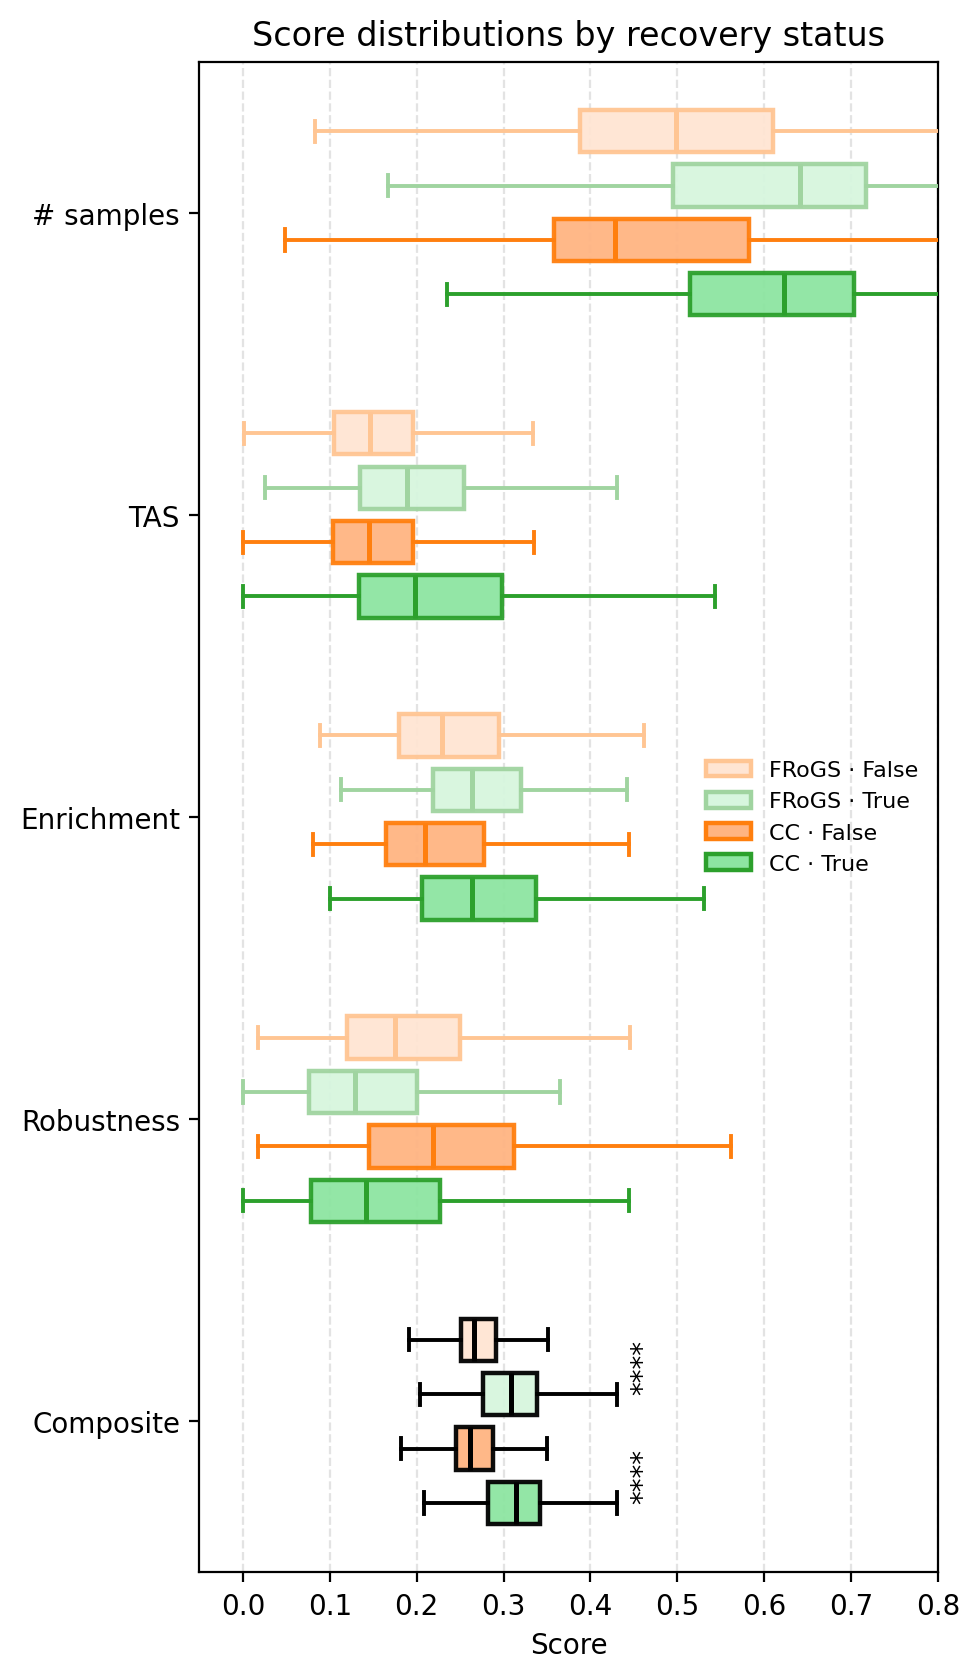

In [22]:
fig, ax = plot_score_boxplots_two_dfs_vertical(
    conf_bench=conf_bench_frogs,
    conf_bench_cc=conf_bench_cc,
    composite_col="composite_score",   # or "composite_score_v2"
    figsize=(5, 8.5),
    showfliers=False,
    title="Score distributions by recovery status",
)
plt.show()

## JOIN ALL FIGURES

In [ ]:
import ast
import re
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors

from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator, FormatStrFormatter, PercentFormatter
from scipy.stats import mannwhitneyu


# =========================================================
# Global plotting style
# =========================================================
TITLE_FONTSIZE = 10
LABEL_FONTSIZE = 9
TICK_FONTSIZE = 8
LEGEND_FONTSIZE = 7
PANEL_FONTSIZE = 12

GRID_ALPHA = 0.25
SPINE_LW = 0.8


# =========================================================
# Helpers
# =========================================================
def _to_clean_set(x):
    if x is None or pd.isna(x):
        return set()

    if isinstance(x, (list, tuple, set, np.ndarray)):
        items = list(x)
    else:
        s = str(x).strip()

        if s.startswith("[") and s.endswith("]"):
            try:
                parsed = ast.literal_eval(s)
                if isinstance(parsed, (list, tuple, set)):
                    items = list(parsed)
                else:
                    items = [s]
            except Exception:
                items = [s]
        else:
            items = re.split(r";|\|", s)

    return {
        str(i).strip().casefold()
        for i in items
        if str(i).strip() not in ["", "nan", "None"]
    }


def accuracy_above_threshold_aligned(
    df,
    measure="top_conf",
    thresholds=None,
    top_moa_col="top_moa",
    true_moa_col="true_moa",
):
    d = df.copy()

    d["_top_moa_set"] = d[top_moa_col].apply(_to_clean_set)
    d["_true_moa_set"] = d[true_moa_col].apply(_to_clean_set)

    d["is_true"] = [
        len(a & b) > 0
        for a, b in zip(d["_top_moa_set"], d["_true_moa_set"])
    ]

    d = d[d[measure].notna()].copy()

    if thresholds is None:
        thresholds = np.linspace(0, 1, 21)

    rows = []
    for t in thresholds:
        subset = d[d[measure] >= t]
        n = len(subset)
        n_true = int(subset["is_true"].sum()) if n > 0 else 0
        pct_true = 100 * n_true / n if n > 0 else np.nan

        rows.append({
            "threshold": t,
            "n_compounds": n,
            "n_true": n_true,
            "pct_true": pct_true,
        })

    return pd.DataFrame(rows), d


def _make_moa_count_table(series):
    out = series.dropna().value_counts().reset_index()
    out.columns = ["top_moa", "count"]
    return out


def _clean_axis(ax, remove_top=True, remove_right=True):
    if remove_top:
        ax.spines["top"].set_visible(False)
    if remove_right:
        ax.spines["right"].set_visible(False)

    for spine in ax.spines.values():
        spine.set_linewidth(SPINE_LW)

    ax.tick_params(axis="both", labelsize=TICK_FONTSIZE, width=SPINE_LW)


def _add_panel_label(ax, label, x=-0.18, y=1.08):
    ax.text(
        x, y, label,
        transform=ax.transAxes,
        fontsize=PANEL_FONTSIZE,
        fontweight="bold",
        va="top",
        ha="left",
    )


# =========================================================
# PANEL A
# =========================================================
def draw_panel_A(
    ax_top,
    ax_bottom,
    compound_top_c,
    compound_top_filtered,
    conf_threshold=0.25,
    bins=None,
):
    if bins is None:
        bins = np.linspace(0, 1, 21)

    threshold_df, checked_df = accuracy_above_threshold_aligned(
        compound_top_filtered,
        measure="top_conf",
        thresholds=bins,
        top_moa_col="top_moa",
        true_moa_col="true_moa",
    )

    base_color = sns.color_palette("pastel")[4]
    edge_color = sns.color_palette("tab10")[4]
    light_color = tuple(min(1, c + (1 - c) * 0.65) for c in base_color)

    # top line
    ax_top.plot(
        threshold_df["threshold"],
        threshold_df["pct_true"],
        color=edge_color,
        linewidth=1.6,
        marker="o",
        markersize=3.0,
        markerfacecolor=base_color,
        markeredgecolor=edge_color,
        markeredgewidth=0.8,
        zorder=4,
    )
    ax_top.axvline(conf_threshold, color="black", linestyle="--", linewidth=0.9, zorder=5)

    ax_top.set_ylabel("% correct\nannotated", fontsize=LABEL_FONTSIZE)
    ax_top.set_ylim(0, 103)
    ax_top.set_yticks([0, 50, 100])
    ax_top.tick_params(axis="x", labelbottom=False)
    ax_top.grid(True, alpha=GRID_ALPHA, ls="--", zorder=0)
    ax_top.set_axisbelow(True)
    _clean_axis(ax_top)

    # bottom histogram
    sns.histplot(
        compound_top_c["top_conf"].dropna(),
        bins=bins,
        color=base_color,
        edgecolor="black",
        linewidth=0.8,
        ax=ax_bottom,
        zorder=3,
    )

    for patch in ax_bottom.patches:
        if patch.get_x() + patch.get_width() <= conf_threshold:
            patch.set_facecolor(light_color)

    ax_bottom.axvline(conf_threshold, color="black", linestyle="--", linewidth=0.9, zorder=5)
    ax_bottom.text(
        conf_threshold + 0.015,
        ax_bottom.get_ylim()[1] * 0.90,
        f"threshold = {conf_threshold:.2f}",
        ha="left",
        va="top",
        fontsize=LEGEND_FONTSIZE,
    )

    ax_bottom.set_xlabel("Confidence score", fontsize=LABEL_FONTSIZE)
    ax_bottom.set_ylabel("# unannotated compounds", fontsize=LABEL_FONTSIZE)
    ax_bottom.set_xlim(0, 1)
    ax_bottom.set_xticks(np.arange(0, 1.01, 0.25))
    ax_bottom.grid(True, alpha=GRID_ALPHA, ls="--", zorder=0)
    ax_bottom.set_axisbelow(True)
    _clean_axis(ax_bottom)

    ax_top.set_title("Confidence score calibration", fontsize=TITLE_FONTSIZE, pad=6)
    _add_panel_label(ax_top, "A", x=-0.20, y=1.18)

    return threshold_df, checked_df


# =========================================================
# PANEL B
# =========================================================
def draw_panel_B(ax, labels, moa_arr, embs_tsne):
    labels_arr = np.asarray(labels)
    moa_arr_plot = np.asarray(moa_arr)

    is_external = labels_arr == "Unannotated"
    plot_order = list(np.unique(moa_arr_plot))

    palette = dict(zip(plot_order, sns.color_palette("pastel", n_colors=len(plot_order))))

    for moa in plot_order:
        mask = (~is_external) & (moa_arr_plot == moa)
        if mask.sum() == 0:
            continue
        sns.scatterplot(
            ax=ax,
            x=embs_tsne[mask, 0],
            y=embs_tsne[mask, 1],
            hue=np.repeat(moa, mask.sum()),
            hue_order=plot_order,
            palette=palette,
            s=18,
            edgecolor=None,
            legend=False,
            alpha=1,
        )

    for i, moa in enumerate(plot_order):
        mask = is_external & (moa_arr_plot == moa)
        if mask.sum() == 0:
            continue
        sns.scatterplot(
            ax=ax,
            x=embs_tsne[mask, 0],
            y=embs_tsne[mask, 1],
            hue=np.repeat(moa, mask.sum()),
            hue_order=plot_order,
            palette=palette,
            s=12,
            edgecolor="black",
            linewidth=0.7,
            legend=(i == len(plot_order) - 1),
        )

    ax.axis("off")
    ax.set_title("Exemplary compounds", fontsize=TITLE_FONTSIZE, pad=6)

    xpad = (embs_tsne[:, 0].max() - embs_tsne[:, 0].min()) * 0.05
    ypad = (embs_tsne[:, 1].max() - embs_tsne[:, 1].min()) * 0.05
    ax.set_xlim(embs_tsne[:, 0].min() - xpad, embs_tsne[:, 0].max() + xpad)
    ax.set_ylim(embs_tsne[:, 1].min() - ypad, embs_tsne[:, 1].max() + ypad)

    leg = ax.legend(
        loc="upper center",
        frameon=False,
        bbox_to_anchor=(0.5, -0.03),
        ncols=2,
        fontsize=LEGEND_FONTSIZE,
        handletextpad=0.3,
        columnspacing=0.8,
    )
    if leg is not None:
        for text in leg.get_texts():
            text.set_fontsize(LEGEND_FONTSIZE)

    _add_panel_label(ax, "B", x=-0.08, y=1.05)


# =========================================================
# PANEL C
# =========================================================
def _shorten_moa_label(x):
    """
    Shorten MoA names for compact plotting while preserving meaning.
    """
    s = str(x)

    replacements = {
        "inhibitor": "inh.",
        "agonist": "ago.",
        "antagonist": "antag.",
        "receptor": "rec.",
        "modulator": "mod.",
        "sensitizer": "sens.",
        "Tyrosine kinase": "TK",
        "Protein synthesis": "Prot. synth.",
        "Estrogen": "ER",
        "Dopamine": "DA",
        "Glucocorticoid": "GC",
        "Insulin": "Ins.",
    }

    for old, new in replacements.items():
        s = s.replace(old, new)

    s = " ".join(s.split())
    return s


def draw_panel_C(
    ax,
    compound_top_c,
    conf_threshold=0.25,
    top_n=10,
    top_moas_from="filtered",
):
    counts_total_all = _make_moa_count_table(compound_top_c["top_moa"])

    counts_filtered_all = _make_moa_count_table(
        compound_top_c.loc[
            compound_top_c["top_conf"] > conf_threshold,
            "top_moa"
        ]
    )

    if top_moas_from == "filtered":
        top_moas = (
            counts_filtered_all
            .sort_values("count", ascending=False)
            .head(top_n)["top_moa"]
            .values
        )
    else:
        top_moas = (
            counts_total_all
            .sort_values("count", ascending=False)
            .head(top_n)["top_moa"]
            .values
        )

    total_lookup = counts_total_all.set_index("top_moa")["count"]
    filt_lookup = counts_filtered_all.set_index("top_moa")["count"]

    plot_moa_df = pd.DataFrame({
        "top_moa": top_moas,
        "count_all": total_lookup.reindex(top_moas, fill_value=0).values,
        "count_filt": filt_lookup.reindex(top_moas, fill_value=0).values,
    })

    n_total = counts_total_all["count"].sum()

    plot_moa_df["perc_all"] = plot_moa_df["count_all"] / n_total * 100
    plot_moa_df["perc_filt"] = plot_moa_df["count_filt"] / n_total * 100

    # keep one-line abbreviated labels
    plot_moa_df["top_moa_short"] = plot_moa_df["top_moa"].apply(_shorten_moa_label)

    base_color = sns.color_palette("pastel")[4]

    # --------------------------------------------------
    # Keep your original overlaid / stacked visual style
    # --------------------------------------------------
    sns.barplot(
        data=plot_moa_df,
        y="top_moa_short",
        x="perc_all",
        color="lightgray",
        edgecolor="black",
        linewidth=0.8,
        ax=ax,
        label="All compounds",
        zorder=3,
    )

    sns.barplot(
        data=plot_moa_df,
        y="top_moa_short",
        x="perc_filt",
        color=base_color,
        edgecolor="black",
        linewidth=0.8,
        ax=ax,
        label="After filtering",
        zorder=4,
    )

    ax.set_xlabel("Percentage of compounds (%)", fontsize=LABEL_FONTSIZE)
    ax.set_ylabel("")
    ax.set_title("Top predicted MoAs", fontsize=TITLE_FONTSIZE, pad=6)

    ax.tick_params(axis="y", labelsize=7, pad=2)
    ax.tick_params(axis="x", labelsize=TICK_FONTSIZE)

    ax.legend(
        frameon=False,
        fontsize=LEGEND_FONTSIZE,
        loc="lower right",
    )

    ax.grid(axis="x", linestyle="--", alpha=0.6, zorder=1)
    ax.set_axisbelow(True)

    _clean_axis(ax)
    _add_panel_label(ax, "C", x=-0.18, y=1.05)

    return plot_moa_df

# =========================================================
# PANEL D helpers
# =========================================================
def _rank_transform(x, breakpoint=100, compress_after=0.05):
    x = np.asarray(x, dtype=float)
    return np.where(
        x <= breakpoint,
        x,
        breakpoint + (x - breakpoint) * compress_after
    )


def _rank_ticks(max_val, breakpoint=100):
    # menos ticks antes de 100 para que no solapen
    ticks_pre = list(range(0, breakpoint + 1, 20))
    ticks_post_candidates = [500, 1000, 2000, 5000, 10000]
    ticks_post = [t for t in ticks_post_candidates if t <= max_val]
    return ticks_pre + ticks_post


# =========================================================
# PANEL D
# =========================================================
def draw_panel_D_rank_lollipop(
    ax,
    plot_df,
    title="Observed vs null rank",
    observed_col="rank1",
    null_mean_col="null_rank1_mean",
    null_std_col="null_rank1_std",
    compound_col="compound",
    breakpoint=100,
    compress_after=0.05,
    xmin_raw=-5,
):
    d = plot_df.copy()

    y = np.arange(len(d))
    observed = d[observed_col].astype(float).values
    null_mean = d[null_mean_col].astype(float).values
    null_std = d[null_std_col].astype(float).values

    null_color = sns.color_palette("pastel")[7]
    null_edge = "gray"
    obs_face = sns.color_palette("pastel")[0]
    obs_edge = sns.color_palette("tab10")[0]

    obs_t = _rank_transform(observed, breakpoint=breakpoint, compress_after=compress_after)
    mean_t = _rank_transform(null_mean, breakpoint=breakpoint, compress_after=compress_after)

    left_raw = np.clip(null_mean - null_std, 0, None)
    right_raw = null_mean + null_std

    left_t = _rank_transform(left_raw, breakpoint=breakpoint, compress_after=compress_after)
    right_t = _rank_transform(right_raw, breakpoint=breakpoint, compress_after=compress_after)

    xerr_left = mean_t - left_t
    xerr_right = right_t - mean_t
    xerr = np.vstack([xerr_left, xerr_right])

    valid_null = np.isfinite(mean_t) & np.isfinite(xerr_left) & np.isfinite(xerr_right)
    ax.errorbar(
        mean_t[valid_null], y[valid_null],
        xerr=xerr[:, valid_null],
        fmt="o",
        color=null_edge,
        ecolor=null_color,
        elinewidth=2,
        capsize=3,
        markerfacecolor="white",
        markeredgecolor=null_edge,
        markeredgewidth=1.5,
        markersize=5.5,
        label="Shuffle null",
        zorder=3,
    )

    valid_obs = np.isfinite(obs_t)
    ax.scatter(
        obs_t[valid_obs], y[valid_obs],
        s=45,
        color=obs_face,
        edgecolor=obs_edge,
        linewidth=1.0,
        label="Observed target",
        zorder=5,
    )

    ax.set_yticks(y)
    ax.set_yticklabels(d[compound_col], fontsize=TICK_FONTSIZE)
    ax.invert_yaxis()

    max_val = np.nanmax([np.nanmax(observed), np.nanmax(null_mean + null_std)])
    xmax_raw = max_val * 1.05

    tick_vals = _rank_ticks(xmax_raw, breakpoint=breakpoint)
    tick_pos = _rank_transform(tick_vals, breakpoint=breakpoint, compress_after=compress_after)
    ax.set_xticks(tick_pos)
    ax.set_xticklabels([str(t) for t in tick_vals], fontsize=7)

    xmin_t = _rank_transform([xmin_raw], breakpoint=breakpoint, compress_after=compress_after)[0]
    xmax_t = _rank_transform([xmax_raw], breakpoint=breakpoint, compress_after=compress_after)[0]
    ax.set_xlim(xmin_t, xmax_t)

    bp_t = _rank_transform([breakpoint], breakpoint=breakpoint, compress_after=compress_after)[0]
    ax.axvline(bp_t, color="0.75", lw=0.8, alpha=0.55, zorder=0)

    ax.set_xlabel("Target rank\n(lower = better)", fontsize=LABEL_FONTSIZE)
    ax.set_title(title, fontsize=TITLE_FONTSIZE, pad=6)
    ax.grid(axis="x", linestyle="--", alpha=0.3)
    _clean_axis(ax)

    # leyenda más centrada para no molestar
    handles, labels_ = ax.get_legend_handles_labels()
    order = [labels_.index("Observed target"), labels_.index("Shuffle null")]
    ax.legend(
        [handles[i] for i in order],
        [labels_[i] for i in order],
        frameon=False,
        fontsize=LEGEND_FONTSIZE,
        loc="lower center",
        bbox_to_anchor=(0.55, 0.01),
        ncol=1,
    )

    _add_panel_label(ax, "D", x=-0.18, y=1.05)


# =========================================================
# PANEL E helpers
# =========================================================
def compute_cumulative_from_rank_summary_selected_compounds(
    rank_summary,
    selected_compounds,
    k_max=100,
    compound_col="compound",
    observed_rank_col="rank1",
    null_mean_col="null_rank1_mean",
):
    d = rank_summary.copy()

    d = d[
        d[compound_col].isin(selected_compounds)
        & d[observed_rank_col].notna()
        & d[null_mean_col].notna()
    ].copy()

    rows = []
    for k in range(1, k_max + 1):
        observed_frac = (d[observed_rank_col] <= k).mean()
        null_mean_frac = (d[null_mean_col] <= k).mean()

        rows.append({
            "k": k,
            "observed_frac": observed_frac,
            "null_mean_frac": null_mean_frac,
            "n_compounds": len(d),
        })

    return pd.DataFrame(rows), d


# =========================================================
# PANEL E
# =========================================================
def draw_panel_E_combined(
    ax_top,
    ax_bottom,
    conf_bench,
    rank_summary,
    title=None,
    topk=100,
    k_max=100,
    compound_col="compound",
    recover_col="recover",
    observed_rank_col="rank1",
    null_mean_col="null_rank1_mean",
    show_legend=True,
    show_xlabel=True,
):
    cb = conf_bench.copy()
    cb = cb[cb[compound_col].notna()].copy()
    cb[recover_col] = cb[recover_col].astype(bool)

    n_topk = int(cb[recover_col].sum())
    n_not_topk = int((~cb[recover_col]).sum())
    n_total = len(cb)

    recovered_compounds = (
        cb.loc[cb[recover_col], compound_col]
        .dropna()
        .unique()
        .tolist()
    )

    curve_df, used_rank_df = compute_cumulative_from_rank_summary_selected_compounds(
        rank_summary=rank_summary,
        selected_compounds=recovered_compounds,
        k_max=k_max,
        compound_col=compound_col,
        observed_rank_col=observed_rank_col,
        null_mean_col=null_mean_col,
    )

    # colors
    true_fill = sns.color_palette("pastel")[2]
    false_fill = sns.color_palette("pastel")[1]
    true_edge = sns.color_palette("tab10")[2]
    false_edge = sns.color_palette("tab10")[1]

    observed_fill = sns.color_palette("pastel")[0]
    observed_line = sns.color_palette("tab10")[0]
    null_fill = sns.color_palette("pastel")[7]
    null_line = "gray"

    # top
    labels = [f"In Top-{topk}", f"Not in Top-{topk}"]
    counts = [n_topk, n_not_topk]
    colors = [true_fill, false_fill]
    edges = [true_edge, false_edge]

    y = np.array([1, 0])
    bars = ax_top.barh(
        y, counts,
        color=colors,
        edgecolor=edges,
        linewidth=1.2,
        height=0.50,
        zorder=3,
    )

    ax_top.set_yticks(y)
    ax_top.set_yticklabels(labels, fontsize=8)

    xmax = max(counts) if len(counts) > 0 else 1
    ax_top.set_xlim(0, xmax * 1.12)

    for yi, count, bar in zip(y, counts, bars):
        pct = 100 * count / n_total if n_total > 0 else 0
        txt = f"{count} ({pct:.1f}%)"

        if count > xmax * 0.18:
            x_text = count - xmax * 0.03
            ha = "right"
        else:
            x_text = count + xmax * 0.02
            ha = "left"

        ax_top.text(
            x_text, yi, txt,
            va="center", ha=ha,
            fontsize=8, color="black",
        )

    if title is not None:
        ax_top.set_title(title, fontsize=TITLE_FONTSIZE, pad=3)

    ax_top.tick_params(axis="x", bottom=False, labelbottom=False)
    ax_top.grid(False)
    for spine in ["top", "right", "bottom", "left"]:
        ax_top.spines[spine].set_visible(False)

    # bottom cumulative
    ax_bottom.fill_between(
        curve_df["k"], curve_df["null_mean_frac"], 0,
        step="post", color=null_fill, alpha=0.85,
        label="Shuffle null mean", zorder=2,
    )
    ax_bottom.fill_between(
        curve_df["k"], curve_df["observed_frac"], 0,
        step="post", color=observed_fill, alpha=0.85,
        label="Observed", zorder=1,
    )
    ax_bottom.step(
        curve_df["k"], curve_df["null_mean_frac"],
        where="post", color=null_line, linewidth=1.6, zorder=3,
    )
    ax_bottom.step(
        curve_df["k"], curve_df["observed_frac"],
        where="post", color=observed_line, linewidth=2.0, zorder=4,
    )

    ax_bottom.set_xlim(1, k_max)
    ax_bottom.set_ylim(0, 1.02)
    ax_bottom.yaxis.set_major_formatter(PercentFormatter(1.0))

    if show_xlabel:
        ax_bottom.set_xlabel("Rank threshold (k)", fontsize=LABEL_FONTSIZE)
    else:
        ax_bottom.set_xlabel("")

    ax_bottom.set_ylabel("Fraction\nrank ≤ k", fontsize=8)
    ax_bottom.tick_params(axis="both", labelsize=8)
    ax_bottom.grid(True, linestyle="--", alpha=0.25)
    ax_bottom.set_axisbelow(True)

    if show_legend:
        ax_bottom.legend(frameon=False, loc="upper left", fontsize=7)
    else:
        leg = ax_bottom.get_legend()
        if leg is not None:
            leg.remove()

    _clean_axis(ax_bottom)

    return curve_df, used_rank_df


# =========================================================
# PANEL F helpers
# =========================================================
def _lighten_color(color, amount=0.45):
    c = np.array(mcolors.to_rgb(color))
    white = np.array([1, 1, 1])
    return tuple((1 - amount) * c + amount * white)


def _p_to_star(p):
    if pd.isna(p):
        return ""
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


def _composite_recovery_pvalue(df, composite_col):
    false_vals = df.loc[df["recover"] == False, composite_col].dropna().values
    true_vals = df.loc[df["recover"] == True, composite_col].dropna().values

    if len(false_vals) == 0 or len(true_vals) == 0:
        return np.nan

    return mannwhitneyu(true_vals, false_vals, alternative="greater").pvalue


def _boxplot_upper_whisker(vals):
    vals = pd.Series(vals).dropna().values
    if len(vals) == 0:
        return np.nan

    q1, q3 = np.percentile(vals, [25, 75])
    iqr = q3 - q1
    upper_limit = q3 + 1.5 * iqr
    visible_vals = vals[vals <= upper_limit]

    if len(visible_vals) == 0:
        return np.nanmax(vals)

    return np.nanmax(visible_vals)


# =========================================================
# PANEL F
# =========================================================
def draw_panel_F_scores(
    ax,
    conf_bench,
    conf_bench_cc,
    composite_col="composite_score",
    showfliers=False,
    xlim=(-0.05, 0.8),
    star_dx=0.03,
):
    metric_order = [
        "score_n_sigs",
        "score_tas",
        "score_enrichment",
        "score_robustness",
        composite_col,
    ]

    metric_labels = {
        "score_n_sigs": "# samples",
        "score_tas": "TAS",
        "score_enrichment": "Enrichment",
        "score_robustness": "Robustness",
        composite_col: "Composite",
    }

    cc_true_fill = sns.color_palette("pastel")[2]
    cc_false_fill = sns.color_palette("pastel")[1]
    cc_true_edge = sns.color_palette("tab10")[2]
    cc_false_edge = sns.color_palette("tab10")[1]

    frogs_true_fill = _lighten_color(cc_true_fill, amount=0.65)
    frogs_false_fill = _lighten_color(cc_false_fill, amount=0.65)
    frogs_true_edge = _lighten_color(cc_true_edge, amount=0.55)
    frogs_false_edge = _lighten_color(cc_false_edge, amount=0.55)

    fill_colors = {
        ("conf_bench", False): frogs_false_fill,
        ("conf_bench", True): frogs_true_fill,
        ("conf_bench_cc", False): cc_false_fill,
        ("conf_bench_cc", True): cc_true_fill,
    }

    edge_colors = {
        ("conf_bench", False): frogs_false_edge,
        ("conf_bench", True): frogs_true_edge,
        ("conf_bench_cc", False): cc_false_edge,
        ("conf_bench_cc", True): cc_true_edge,
    }

    dataset_frames = {
        "conf_bench": conf_bench.copy(),
        "conf_bench_cc": conf_bench_cc.copy(),
    }

    group_order = [
        ("conf_bench", False),
        ("conf_bench", True),
        ("conf_bench_cc", False),
        ("conf_bench_cc", True),
    ]

    group_labels = {
        ("conf_bench", False): "FRoGS · False",
        ("conf_bench", True): "FRoGS · True",
        ("conf_bench_cc", False): "CC · False",
        ("conf_bench_cc", True): "CC · True",
    }

    offsets = {
        ("conf_bench", False): -0.27,
        ("conf_bench", True): -0.09,
        ("conf_bench_cc", False): 0.09,
        ("conf_bench_cc", True): 0.27,
    }

    box_width = 0.14

    for i, metric in enumerate(metric_order):
        for dataset_name, rec in group_order:
            df = dataset_frames[dataset_name]
            if metric not in df.columns:
                continue

            vals = df.loc[df["recover"] == rec, metric].dropna().values
            if len(vals) == 0:
                continue

            pos = i + offsets[(dataset_name, rec)]
            face = fill_colors[(dataset_name, rec)]
            edge = "black" if metric == composite_col else edge_colors[(dataset_name, rec)]

            bp = ax.boxplot(
                [vals],
                positions=[pos],
                widths=box_width,
                vert=False,
                patch_artist=True,
                showfliers=showfliers,
                manage_ticks=False,
                zorder=3,
            )

            for box in bp["boxes"]:
                box.set(facecolor=face, edgecolor=edge, linewidth=1.4, alpha=0.95)
            for whisker in bp["whiskers"]:
                whisker.set(color=edge, linewidth=1.2)
            for cap in bp["caps"]:
                cap.set(color=edge, linewidth=1.2)
            for median in bp["medians"]:
                median.set(color=edge, linewidth=1.6)

    ax.set_yticks(np.arange(len(metric_order)))
    ax.set_yticklabels([metric_labels[m] for m in metric_order], fontsize=TICK_FONTSIZE)
    ax.set_ylim(len(metric_order) - 0.5, -0.5)

    composite_i = metric_order.index(composite_col)
    composite_stats = {
        "conf_bench": _composite_recovery_pvalue(conf_bench, composite_col),
        "conf_bench_cc": _composite_recovery_pvalue(conf_bench_cc, composite_col),
    }

    star_y = {
        "conf_bench": composite_i + (offsets[("conf_bench", False)] + offsets[("conf_bench", True)]) / 2,
        "conf_bench_cc": composite_i + (offsets[("conf_bench_cc", False)] + offsets[("conf_bench_cc", True)]) / 2,
    }

    star_x = {}
    for dataset_name, df in {"conf_bench": conf_bench, "conf_bench_cc": conf_bench_cc}.items():
        vals_false = df.loc[df["recover"] == False, composite_col].dropna().values
        vals_true = df.loc[df["recover"] == True, composite_col].dropna().values

        right_false = _boxplot_upper_whisker(vals_false)
        right_true = _boxplot_upper_whisker(vals_true)
        right_edge = np.nanmax([right_false, right_true])
        star_x[dataset_name] = right_edge + star_dx

    for dataset_name, pval in composite_stats.items():
        star = _p_to_star(pval)
        if star in ("", "ns"):
            continue
        ax.text(
            star_x[dataset_name],
            star_y[dataset_name],
            star,
            va="center",
            ha="center",
            rotation=90,
            fontsize=9,
            color="black",
            zorder=10,
        )

    ax.set_xlabel("Score", fontsize=LABEL_FONTSIZE)
    ax.set_ylabel("")
    ax.set_title("Score distributions by recovery status", fontsize=TITLE_FONTSIZE, pad=6)

    ax.xaxis.set_major_locator(MultipleLocator(0.1))
    ax.xaxis.set_major_formatter(FormatStrFormatter("%.1f"))
    ax.set_xlim(xlim)

    ax.grid(axis="x", linestyle="--", alpha=0.35, zorder=0)
    ax.set_axisbelow(True)
    _clean_axis(ax)

    legend_handles = [
        Patch(
            facecolor=fill_colors[key],
            edgecolor=edge_colors[key],
            linewidth=1.4,
            label=group_labels[key],
        )
        for key in group_order
    ]

    ax.legend(
        handles=legend_handles,
        frameon=False,
        loc="center right",
        fontsize=7,
    )

    _add_panel_label(ax, "F", x=-0.18, y=1.05)

In [ ]:
def plot_full_figure_ABCDEF(
    compound_top_c,
    compound_top_filtered,
    labels,
    moa_arr,
    embs_tsne,
    rank_summary_D,
    rank_summary_cc,
    rank_summary_frogs,
    conf_bench_cc,
    conf_bench_frogs,
    conf_threshold=0.25,
    bins=None,
    top_n=10,
    figsize=(18, 10),
):
    if bins is None:
        bins = np.linspace(0, 1, 21)

    fig = plt.figure(figsize=figsize, dpi=300, facecolor="white")

    # menos espacio vertical entre filas
    gs = fig.add_gridspec(
        2, 3,
        height_ratios=[0.72, 1.45],
        width_ratios=[1.05, 1.05, 1.15],
        hspace=0.40,
        wspace=0.38,
    )

    # =========================
    # Row 1
    # =========================
    gsA = gs[0, 0].subgridspec(
        2, 1,
        height_ratios=[0.42, 1.35],
        hspace=0.03,
    )
    axA_top = fig.add_subplot(gsA[0])
    axA_bottom = fig.add_subplot(gsA[1], sharex=axA_top)

    axB = fig.add_subplot(gs[0, 1])
    axC = fig.add_subplot(gs[0, 2])

    # =========================
    # Row 2
    # =========================
    axD = fig.add_subplot(gs[1, 0])

    # E más compacta
    gsE = gs[1, 1].subgridspec(
        4, 1,
        height_ratios=[0.15, 0.30, 0.15, 0.30],
        hspace=0.5,
    )
    axE1_top = fig.add_subplot(gsE[0])
    axE1_bottom = fig.add_subplot(gsE[1])
    axE2_top = fig.add_subplot(gsE[2])
    axE2_bottom = fig.add_subplot(gsE[3])

    axF = fig.add_subplot(gs[1, 2])

    # =========================
    # Draw A
    # =========================
    threshold_df, checked_df = draw_panel_A(
        ax_top=axA_top,
        ax_bottom=axA_bottom,
        compound_top_c=compound_top_c,
        compound_top_filtered=compound_top_filtered,
        conf_threshold=conf_threshold,
        bins=bins,
    )

    # =========================
    # Draw B
    # =========================
    draw_panel_B(
        ax=axB,
        labels=labels,
        moa_arr=moa_arr,
        embs_tsne=embs_tsne,
    )

    # =========================
    # Draw C
    # =========================
    plot_moa_df = draw_panel_C(
        ax=axC,
        compound_top_c=compound_top_c,
        conf_threshold=conf_threshold,
        top_n=top_n,
        top_moas_from="filtered",
    )

    # =========================
    # Draw D
    # =========================
    rank_summary_D_plot = rank_summary_D.sort_values("rank1", ascending=True).copy()
    draw_panel_D_rank_lollipop(
        ax=axD,
        plot_df=rank_summary_D_plot,
        title="Observed vs null rank",
    )

    # =========================
    # Draw E1
    # =========================
    curve_cc, used_cc = draw_panel_E_combined(
        ax_top=axE1_top,
        ax_bottom=axE1_bottom,
        conf_bench=conf_bench_cc,
        rank_summary=rank_summary_cc,
        title="CC benchmark",
        topk=100,
        k_max=100,
        show_legend=True,
        show_xlabel=False,
    )
    _add_panel_label(axE1_top, "E", x=-0.18, y=1.18)

    # =========================
    # Draw E2
    # =========================
    curve_frogs, used_frogs = draw_panel_E_combined(
        ax_top=axE2_top,
        ax_bottom=axE2_bottom,
        conf_bench=conf_bench_frogs,
        rank_summary=rank_summary_frogs,
        title="FRoGS benchmark",
        topk=100,
        k_max=100,
        show_legend=False,
        show_xlabel=True,
    )

    # =========================
    # Draw F
    # =========================
    draw_panel_F_scores(
        ax=axF,
        conf_bench=conf_bench_frogs,
        conf_bench_cc=conf_bench_cc,
        composite_col="composite_score",
        showfliers=False,
        xlim=(-0.05, 0.8),
        star_dx=0.03,
    )

    # ajuste fino para reducir hueco blanco total
    fig.subplots_adjust(
        left=0.06,
        right=0.985,
        top=0.965,
        bottom=0.06,
    )

    outputs = {
        "threshold_df": threshold_df,
        "checked_df": checked_df,
        "plot_moa_df": plot_moa_df,
        "curve_cc": curve_cc,
        "used_cc": used_cc,
        "curve_frogs": curve_frogs,
        "used_frogs": used_frogs,
    }

    axes = {
        "A_top": axA_top,
        "A_bottom": axA_bottom,
        "B": axB,
        "C": axC,
        "D": axD,
        "E1_top": axE1_top,
        "E1_bottom": axE1_bottom,
        "E2_top": axE2_top,
        "E2_bottom": axE2_bottom,
        "F": axF,
    }

    return fig, axes, outputs

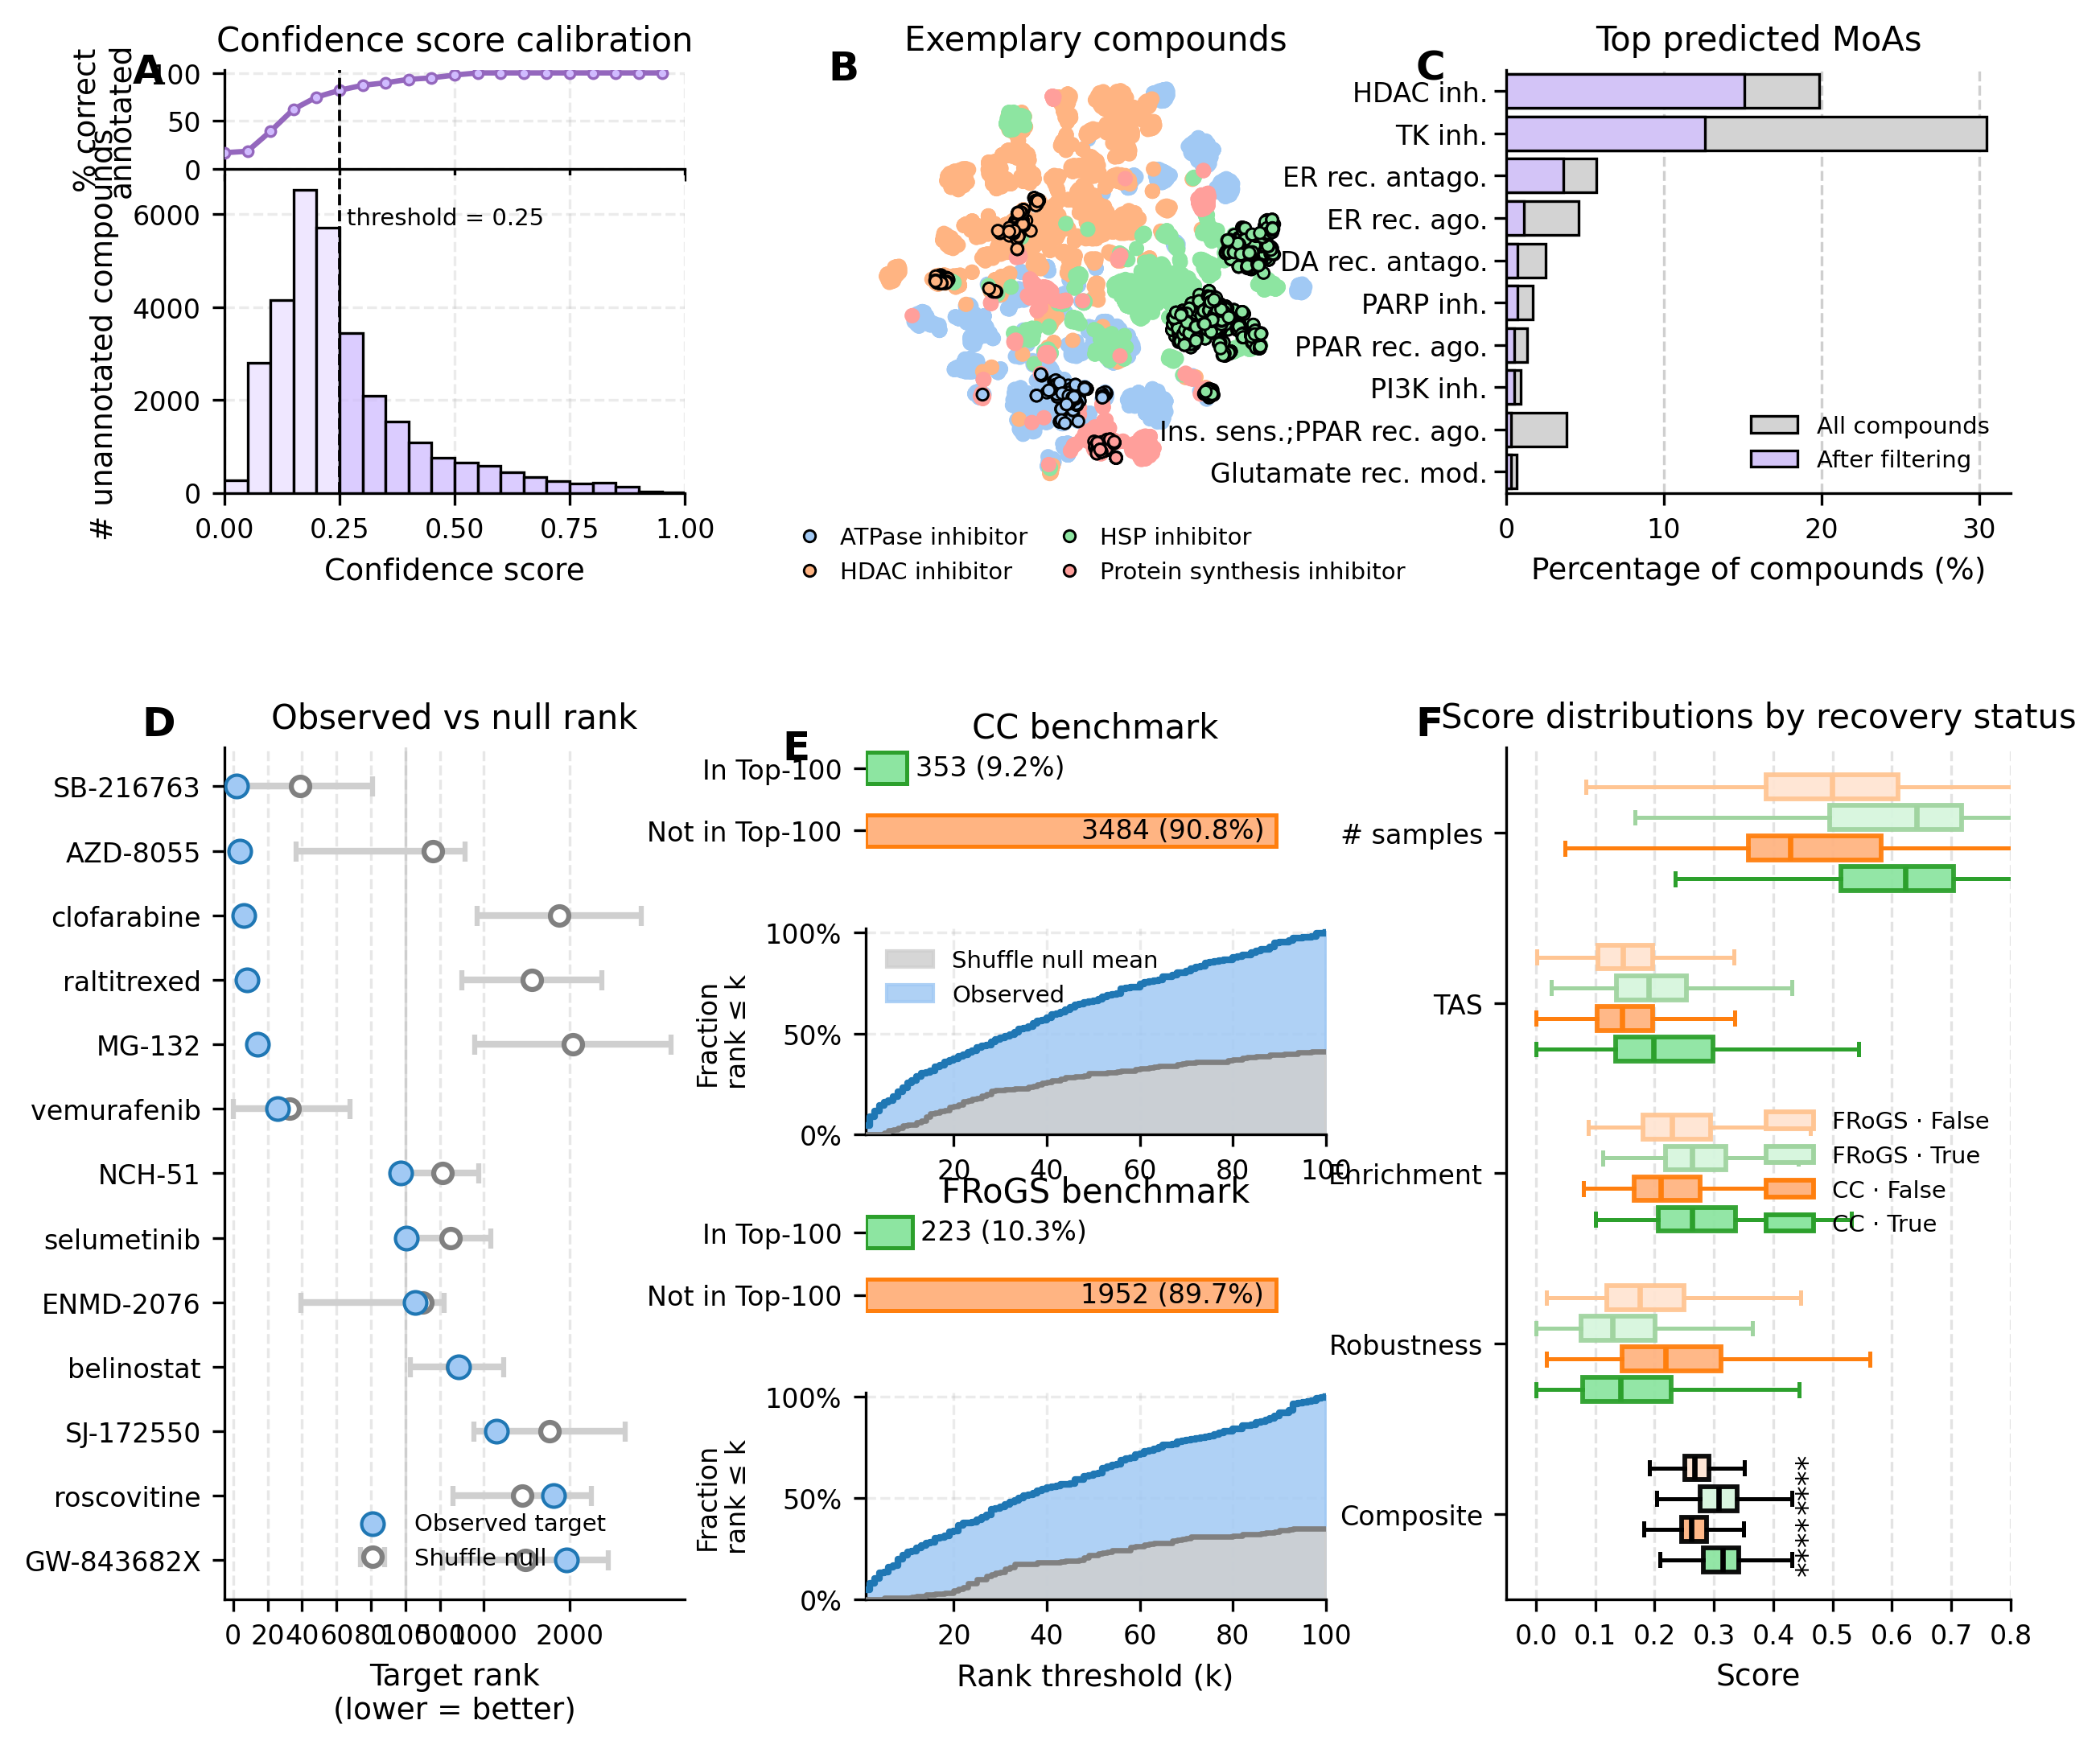

In [ ]:
bins = np.linspace(0, 1, 21)

fig, axes, outputs = plot_full_figure_ABCDEF(
    compound_top_c=compound_top_c,
    compound_top_filtered=compound_top_filtered,
    labels=labels,
    moa_arr=moa_arr,
    embs_tsne=embs_tsne,
    rank_summary_D=rank_summary,
    rank_summary_cc=rank_summary_cc,
    rank_summary_frogs=rank_summary_frogs,
    conf_bench_cc=conf_bench_cc,
    conf_bench_frogs=conf_bench_frogs,
    conf_threshold=0.25,
    bins=bins,
    top_n=10,
    figsize=(8,7),
)

plt.show()